In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
ATAC_path = Path('data') / 'ImmGenATAC18_AllOCRsInfo.csv' #betriebsunabhängiger path erstellt, um auf data zuzugreifen
ATAC_data = pd.read_csv(ATAC_path) #pd liest Datei ab
ATAC_data #head: zeigt nur erste 5 Zeilen --> trotzdem alles geladen

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_1,chr1,3020786,0.00,0.56,NaN,NaN,NaN,0.41,0.71,...,0.10,0.10,3.19,1.37,0.52,1.27,0.10,0.57,3.27,1.41
1,ImmGenATAC1219.peak_2,chr1,3087226,0.00,0.50,NaN,NaN,NaN,0.41,1.64,...,1.70,0.10,1.41,0.47,0.11,0.92,0.98,2.16,2.34,0.94
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512590,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
512591,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64
512592,ImmGenATAC1219.peak_512593,chrY,90813175,0.00,0.69,NaN,NaN,Erdr1,0.41,0.71,...,0.44,1.38,1.20,1.37,1.82,1.61,1.29,0.14,1.23,0.50
512593,ImmGenATAC1219.peak_512594,chrY,90813624,0.00,0.60,NaN,NaN,Erdr1,0.41,1.64,...,0.77,0.97,0.11,1.39,1.39,0.50,0.10,0.14,1.05,0.11


In [2]:
threshold = -np.log10(0.05) #best p value ein th
ATAC_pfiltered = ATAC_data[ATAC_data["_-log10_bestPvalue"] >= threshold].copy()
ATAC_pfiltered.head()
ATAC_pfiltered.__len__() 

362330

# <h1>ATAC-seq: Data Cleanup

<h3>Removing or imputing missing values</h3>

In [3]:
#number of rows
ATAC_data.__len__() 

512595

In [4]:
#number of missing data points per column
missing_values_count = ATAC_data.isnull().sum()
missing_values_count[missing_values_count > 0] #just show columes where data is missing

Included.in.systematic.analysis    177716
TSS                                498303
genes.within.100Kb                  84885
dtype: int64

**Data is missing in 3 columes**: Included.in.systematic.analysis, TSS, genes.within.100Kb  

**included in systematic analysis**: Boolean / yes-no flag indicating whether the authors considered this OCR reliable enough for downstream analyses in the paper
--> NaN: Yoshida et al. do not considerd it reliabale enough for further analysis and did't includ it in further analysis 

**TSS**: name of closest TSS gene
--> NaN: there isn't any TSS gene close to the peak

**genes within 100kb**: just lists all the genes in that range as str
--> NaN: If the peaks are not near any genes within 100 kb

In [5]:
# Wie viel prozent der cells sind missing values
total_cells = np.prod(ATAC_data.shape) #porudkt von ATAC_data.shape also Rows mal Columes
total_missing = missing_values_count.sum()

percent_missing = (total_missing/total_cells) * 100 #prozenanzahl ausrechnen
percent_missing

np.float64(1.5147097670894654)

In [6]:
#values of TSS that are not NaN
just_TSS = ATAC_data.loc[~ATAC_data["TSS"].isnull(), "TSS"] #loc nimmt die Zeilen die True sind also die, die nicht Null sind aus TSS und gibt daraus die Werte wieder zurück
just_TSS

20           Xkr4
139        Mrpl15
145        Lypla1
157         Tcea1
159         Tcea1
           ...   
512467      Vamp7
512477      Tmlhe
512506    Eif2s3y
512522        Uty
512532      Ddx3y
Name: TSS, Length: 14292, dtype: str

In [7]:
#Wie viele prozent cells missing in TSS (enhancer)
TSS_total_missing = ATAC_data ["TSS"].isnull().sum() 
TSS_total_cells = len(ATAC_data)
print(ATAC_data ["TSS"].notnull().sum())

percent_missing_TSS = (TSS_total_missing/TSS_total_cells) * 100
print(percent_missing_TSS)

14292
97.21183390395926


es fehlen **97%** der Werte in TSS --> weil diese nicht in der Nähe einer TSS sind --> distal enahncers

In [8]:
#values of Included.in.systematic.analysis that are not NaN
ATAC_data["Included.in.systematic.analysis"].notnull().sum()

just_Incl_sa = ATAC_data.loc[ATAC_data["Included.in.systematic.analysis"].notnull(),"Included.in.systematic.analysis"]
just_Incl_sa

2         1.0
3         1.0
5         1.0
6         1.0
7         1.0
         ... 
512587    1.0
512588    1.0
512589    1.0
512590    1.0
512591    1.0
Name: Included.in.systematic.analysis, Length: 334879, dtype: float64

**Rauswerfen Daten nicht reliabel Sysematic analysis of paper**
--> also included in systematic analysis = NaN

<h3>P-value filtering</h3>

In [9]:
Minimum_pvalues = ATAC_data["_-log10_bestPvalue"].min()
ATAC_data.sort_values(by=["_-log10_bestPvalue"])

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
64295,ImmGenATAC1219.peak_64296,chr10,122421608,0.00,0.00,NaN,NaN,Avpr1a,0.41,0.10,...,0.10,0.10,0.11,0.11,0.11,0.11,0.34,0.11,0.11,0.11
508409,ImmGenATAC1219.peak_508410,chrX,106733598,0.00,0.00,NaN,NaN,NaN,0.41,0.10,...,0.10,0.29,0.11,0.47,0.52,0.14,0.10,0.11,0.51,0.11
506621,ImmGenATAC1219.peak_506622,chrX,80992224,0.67,0.22,NaN,NaN,Tmem47,0.41,0.10,...,0.44,0.36,0.11,0.11,0.11,0.53,0.10,2.16,1.61,0.11
501817,ImmGenATAC1219.peak_501818,chrUn_GL456390,17745,0.00,0.23,NaN,NaN,NaN,0.41,0.10,...,0.10,0.10,0.71,0.11,0.11,0.14,0.26,0.53,0.51,0.11
450165,ImmGenATAC1219.peak_450166,chr8,3343174,0.00,0.23,NaN,NaN,"Insr,A430078G23Rik,Arhgef18",0.41,0.10,...,0.10,0.10,0.11,0.11,0.11,0.11,0.10,0.11,0.64,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212977,ImmGenATAC1219.peak_212978,chr17,34000401,0.25,inf,1.0,H2-K1,"Platr17,BC051226,Daxx,Zbtb22,Tapbp,Rgl2,Pfdn6,...",57.63,52.34,...,104.36,106.10,79.63,115.50,103.96,66.25,98.69,98.72,66.62,110.97
501969,ImmGenATAC1219.peak_501970,chrUn_JH584304,55702,0.51,inf,1.0,NaN,Pisd-ps3,159.55,163.88,...,85.79,92.83,412.74,47.16,64.12,43.49,141.82,36.14,95.08,27.71
501973,ImmGenATAC1219.peak_501974,chrUn_JH584304,59065,0.00,inf,1.0,NaN,Pisd-ps3,90.52,145.41,...,253.14,174.38,321.14,225.03,225.22,108.31,225.58,108.38,282.02,256.03
501975,ImmGenATAC1219.peak_501976,chrUn_JH584304,59733,0.00,inf,1.0,Pisd-ps3,Pisd-ps3,727.42,727.42,...,727.42,727.42,727.42,727.42,727.42,727.42,727.42,727.42,727.42,727.42


In [10]:
logp_threshold_data = ATAC_data[ATAC_data["_-log10_bestPvalue"] < -np.log10(0.05)] #nach p=0.05 filtern
len(logp_threshold_data)

150265

**Teil von p value filtering: colume: _-log10_bestPvalue**

<br> untersuchen Datnesätze nach auffälligen niedrigen vs hohen p-values

wenn 0 dann heißt es p-value 1 --> Effekt wahrscheinlich rein zufällig zufällig (**entfernen?**)
wenn inf dann p-value fast 0 Sehr signifikant 

logp_threshold alle die kleiner sind als ein p von 0.05 --> signifikante Werte

inf als 0 ersetzen?

*TO BE CONTINUED*

In [11]:
not_Incl_sa = ATAC_data["Included.in.systematic.analysis"].isnull()
logp_threshold_data = ATAC_data["_-log10_bestPvalue"] < -np.log10(0.05)
ATAC_data[not_Incl_sa & logp_threshold_data]

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_1,chr1,3020786,0.00,0.56,NaN,NaN,NaN,0.41,0.71,...,0.10,0.10,3.19,1.37,0.52,1.27,0.10,0.57,3.27,1.41
1,ImmGenATAC1219.peak_2,chr1,3087226,0.00,0.50,NaN,NaN,NaN,0.41,1.64,...,1.70,0.10,1.41,0.47,0.11,0.92,0.98,2.16,2.34,0.94
10,ImmGenATAC1219.peak_11,chr1,3445768,0.00,0.84,NaN,NaN,NaN,0.41,0.10,...,0.87,0.54,0.11,1.37,0.11,0.11,0.98,1.12,1.04,0.11
12,ImmGenATAC1219.peak_13,chr1,3505885,0.01,0.62,NaN,NaN,NaN,0.41,0.71,...,0.44,0.54,0.23,0.11,0.51,1.59,2.23,1.33,3.39,0.93
15,ImmGenATAC1219.peak_16,chr1,3535704,0.03,1.09,NaN,NaN,NaN,0.41,0.10,...,1.70,1.41,2.58,0.95,0.11,1.56,0.88,1.33,1.23,7.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512563,ImmGenATAC1219.peak_512564,chrY,90797463,0.00,0.65,NaN,NaN,Erdr1,2.36,0.10,...,1.60,1.83,0.66,1.39,2.19,0.50,0.75,0.90,1.04,0.11
512566,ImmGenATAC1219.peak_512567,chrY,90798663,0.00,0.91,NaN,NaN,Erdr1,0.41,2.57,...,2.23,1.79,0.23,0.47,3.63,2.82,1.75,1.73,1.64,1.03
512574,ImmGenATAC1219.peak_512575,chrY,90802747,0.00,1.21,NaN,NaN,Erdr1,0.41,0.10,...,1.93,0.36,0.59,2.24,2.90,1.61,1.91,3.83,1.64,2.97
512592,ImmGenATAC1219.peak_512593,chrY,90813175,0.00,0.69,NaN,NaN,Erdr1,0.41,0.71,...,0.44,1.38,1.20,1.37,1.82,1.61,1.29,0.14,1.23,0.50


<p style="color: pink;">Pre-Filtering in Yoshida </p>
included in systematic analysis Werte die NaN sind, haben yoshida et al. rausgenommen, weil die Ihnen zu unverlässig waren. <br>
Wir haben alle Werte gefiltert die ein größeren p value haben als 0.05, also für uns nicht verlässlich. Diese sind weniger als die Yoshida et al. nicht included haben, aber alle 150265 fallen darunter.

<h3>Blacklist Filtering</h3>

In [12]:
cols = [
    "gene_name",
    "transcript_name",
    "chrom",
    "strand",
    "txStart",
    "txEnd",
    "cdsStart",
    "cdsEnd",
    "exonCount",
    "exonStarts",
    "exonEnds"
]
ATAC_path_geanno = Path('data') / "Gene annotations.txt"

Gen_annotations = pd.read_csv(ATAC_path_geanno, sep="\t", names=cols)
# need to tell pandas that the txt is tab (\) seperated
Gen_annotations.head()


,gene_name,transcript_name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds
0,Wdsub1,NM_001159636,chr2,-,59855193,59882606,59855270,59878527,11,"59855193,59858609,59861560,59862619,59862816,5...","59855275,59858750,59861737,59862726,59862857,5..."
1,Rbm18,NM_001159635,chr2,-,36116078,36136704,36117814,36134247,6,"36116078,36120812,36122851,36127214,36134134,3...","36117974,36120898,36122938,36127251,36134263,3..."
2,Prrc2b,NM_001159634,chr2,+,32151147,32234537,32182511,32230742,32,"32151147,32182457,32183122,32185344,32187480,3...","32151291,32182626,32183300,32185447,32187553,3..."
3,Ildr2,NM_001164528,chr1,+,166254138,166316832,166254375,166310795,10,"166254138,166269304,166270498,166291415,166294...","166254466,166269637,166270618,166291472,166294..."
4,Perm1,NM_172417,chr4,+,156215926,156221307,156217000,156220222,4,"156215926,156216716,156219740,156220109,","156215975,156219185,156219866,156221307,"


In [13]:
ATAC_path_blacklist = Path('data') / 'mm10.blacklist.bed'
ATAC_blacklist_data = pd.read_csv(ATAC_path_blacklist)
ATAC_blacklist_data.head()
ATAC_blacklist_data.__len__()

163

In [14]:
Gen_annotations[Gen_annotations["txStart"] == 59855193]
(Gen_annotations['txStart'] == 59855193).any #positiv Probe wird gefunden

<bound method Series.any of 0         True
1        False
2        False
3        False
4        False
         ...  
47377    False
47378    False
47379    False
47380    False
47381    False
Name: txStart, Length: 47382, dtype: bool>

In [15]:
Gen_annotations[Gen_annotations["txStart"] == 24541940]
#or
(Gen_annotations["txStart"] == 24541940).any() #Start von blacklisted Beispiel-gen ist nicht zu finden

np.False_

Wir haben die blacklisted Gene als Tabelle auslesen lassen und dann die Startnummern mit denen der annotierten Gene im Gene annotations Dataset verglichen. Die blacklisted Gene sind nicht im Gene annotations Dataset wiederzufinden, daher ist davon auszugehen, dass diese blacklisted Gene bereits zu Beginn des Data Cleanups von Yoshida et al. entfernt wurde.

# <h2> Exploration of ATAC-seq data

In [17]:
pd.set_option("display.max_rows", None)  #Probleme dass nicht immer alles angezeigt worden ist (None: keine Begrenzung), aber DataWrangler runter geladen kann alle zeieln sehen    
ATAC_pfiltered.describe()
ATAC_pfiltered.__len__()

/Users/rosavasila/topic04_team03/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512588,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,0.41,7.41,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
512589,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.36,8.79,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
512590,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
512591,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


count    # Anzahl der nicht-NaN Werte
mean     # Mittelwert ohne NaN
std      # Standardabweichung ohne NaN

**--> NaN doch lieber ersetzen?**

<h3> Creating a function for log-tranformation: Tilmann </h3>
log transformation besser, um Werte zu vergleichen

In [18]:
def log_transform(df):
    df_numeric_cols = df.select_dtypes(include=[np.number]).columns
    log_df = df.copy()
    log_df[df_numeric_cols] = np.log1p(log_df[df_numeric_cols])
    return log_df

<h3> Using the log_transform function on the filtered values and creating a histogram </h3>

In [19]:
log_ATAC = log_transform(ATAC_pfiltered)
log_ATAC.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,14.953379,0.067659,2.468100,0.693147,NaN,NaN,1.211941,0.095310,...,0.625938,0.431782,1.313724,0.667829,0.104360,4.164803,2.294553,0.845868,0.712950,0.104360
3,ImmGenATAC1219.peak_4,chr1,14.953820,0.139762,1.391282,0.693147,NaN,NaN,0.343590,0.095310,...,0.364643,1.040277,0.506818,0.104360,0.652325,2.674149,0.683097,0.824175,0.712950,0.104360
4,ImmGenATAC1219.peak_5,chr1,15.031250,0.029559,0.837248,NaN,NaN,NaN,0.343590,0.095310,...,0.364643,0.095310,0.506818,1.026042,0.412110,0.652325,0.559616,0.845868,0.959350,1.704748
5,ImmGenATAC1219.peak_6,chr1,15.039056,0.058269,1.220830,0.693147,NaN,NaN,1.211941,0.970779,...,0.850151,0.254642,0.207014,0.636577,0.104360,0.425268,0.875469,0.641854,1.353255,2.311545
6,ImmGenATAC1219.peak_7,chr1,15.039320,0.364643,1.272566,0.693147,NaN,NaN,0.343590,0.095310,...,0.625938,1.075002,0.463734,0.104360,0.871293,1.275363,0.559616,1.193922,1.205971,2.486572


<Axes: xlabel='Tgd.g2+d17.LN', ylabel='Count'>

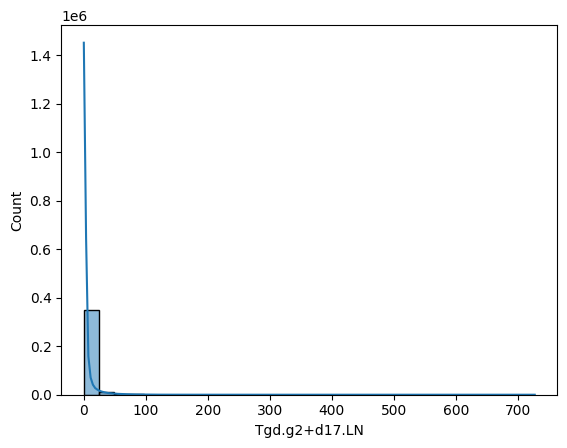

In [20]:
sns.histplot(ATAC_pfiltered["Tgd.g2+d17.LN"], bins=30, kde=True) #kde verteilungskurve

**Verteilung rechtsschief:**
<br> sehr viele Peaks/Regionen haben niedrige ATAC-Signale
<br>wenige Peaks/Regionen haben hohe ATAC-Signale
<br>der lange rechte Schwanz zeigt: einige, aber weige Regionen sind besonders stark zugänglich/open chromatin

<Axes: xlabel='Tgd.g2+d17.LN', ylabel='Count'>

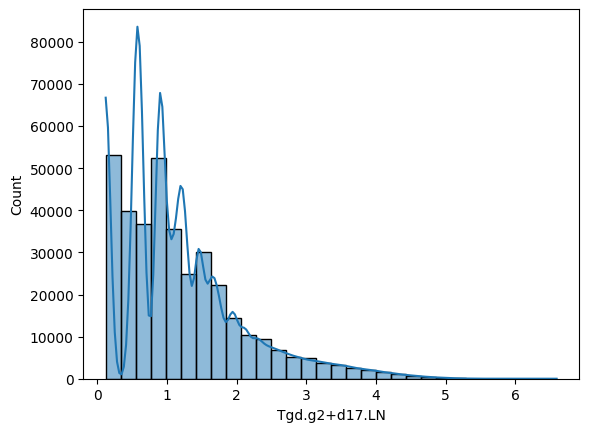

In [21]:
sns.histplot(log_ATAC["Tgd.g2+d17.LN"], bins=30, kde=True) #kde verteilungskurve

mit log besser sehen, wie sich die Datenverteilen

## Filtering by Variation

In [22]:
exclude_cols = [
    "ImmGenATAC1219.peakID",
    "chrom",
    "Summit",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATAC_celltypes = ATAC_pfiltered.drop(columns=exclude_cols).copy()
ATAC_celltypes.head()

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,preB.FrD.BM,B.FrE.BM,B1b.PC,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,2.36,0.10,0.90,0.11,0.47,0.10,0.50,1.17,0.32,0.14,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,0.41,0.10,0.11,0.11,0.79,0.40,0.50,2.23,0.80,0.14,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,0.41,0.10,0.11,0.11,0.47,0.34,1.78,1.17,0.32,0.60,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
5,2.36,1.64,1.85,1.58,1.12,0.34,0.42,0.13,0.80,0.60,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
6,0.41,0.10,0.11,0.11,0.11,1.34,0.90,1.69,0.80,0.60,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02


<Axes: ylabel='Count'>

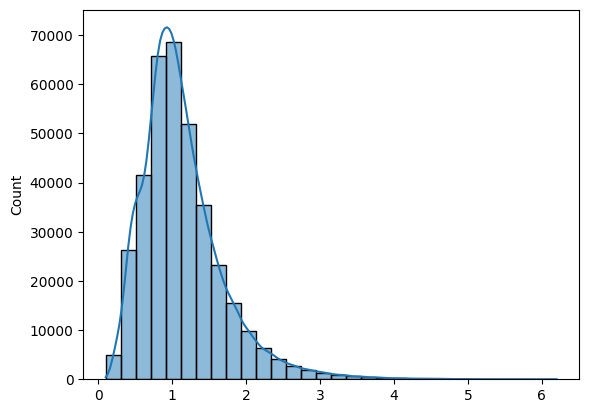

In [23]:
OCR_var_coef = ATAC_celltypes.std(axis=1) / ATAC_celltypes.mean(axis=1)
sns.histplot(OCR_var_coef, bins=30, kde=True)

In [24]:
OCR_var_coef.describe()

count    362330.000000
mean          1.138197
std           0.554413
min           0.103492
25%           0.775821
50%           1.038506
75%           1.387520
max           6.200528
dtype: float64

/var/folders/cc/3r9cpp9s7c9_s16wz91nlkn40000gn/T/ipykernel_42937/485437808.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(np.log2(ATAC_celltypes.mean(axis=1)), OCR_var_coef, s=5, cmap='viridis', alpha=0.5)


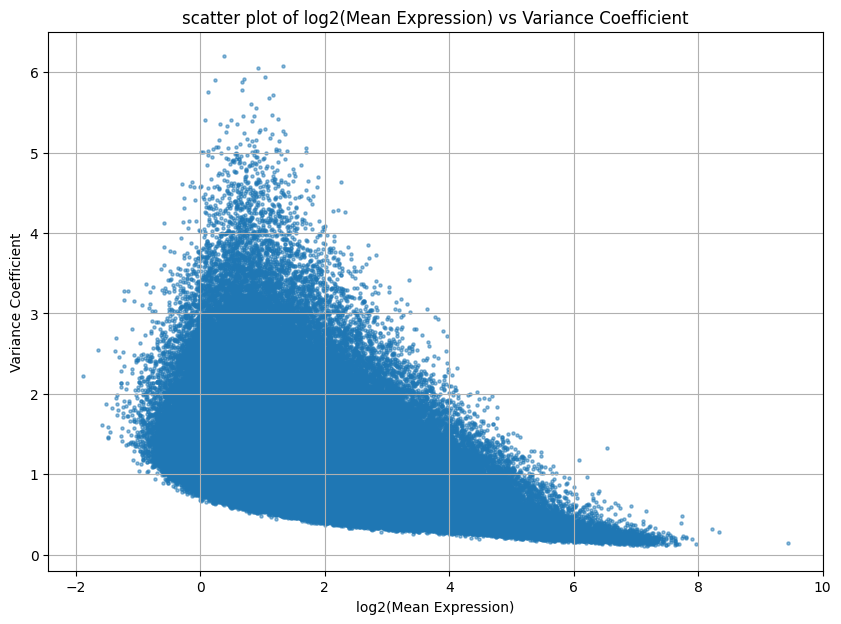

In [25]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(ATAC_celltypes.mean(axis=1)), OCR_var_coef, s=5, cmap='viridis', alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

unten nicht sehr variable Peaks und oben sind einzelne sehr Variable peaks.

# Exploration of QC Dataset

In [26]:
mmc1_path = Path('data') / 'mmc1.xlsx'
mmc1_data = pd.read_excel(mmc1_path)
mmc1_data.head() #head: zeigt nur erste 5 Zeilen --> trotzdem alles geladen


,SampleName,CellType,ImmGenLab,Lineage,CellFamily,Organ,SortingMarkers,InputCellNumber,PF.reads,%chrM.mapped,Paired.read.after.removing.PCR.duplication,%fragment.1Kb_TSS,Replicate.cor
0,LTHSC.34-.BM#1,LTHSC.34-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34-,677,22287984,4.58,2470102,10.60,NaN
1,LTHSC.34+.BM#1,LTHSC.34+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34+,2483,28588536,3.17,7675501,7.70,NaN
2,STHSC.150-.BM#1,STHSC.150-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150-CD48-,3660,22170346,3.25,6060045,11.13,NaN
3,MPP4.135+.BM#1,MPP4.135+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135+,10000,24003590,13.83,6128252,18.96,NaN
4,proB.CLP.BM#1,proB.CLP.BM,Hardy,B,B Cell,Bone Marrow,CD19-IgM-CD43+CD24-CD45R-CD93+CD117+IL7Ra+PI-D...,10000,23578208,7.67,6588564,13.21,0.868


In [27]:
mmc1_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   SampleName                                  181 non-null    str    
 1   CellType                                    181 non-null    str    
 2   ImmGenLab                                   181 non-null    str    
 3   Lineage                                     181 non-null    str    
 4   CellFamily                                  181 non-null    str    
 5   Organ                                       181 non-null    str    
 6   SortingMarkers                              181 non-null    str    
 7   InputCellNumber                             181 non-null    int64  
 8   PF.reads                                    181 non-null    int64  
 9   %chrM.mapped                                181 non-null    float64
 10  Paired.read.after.removin

181 cell samples --> und ATAC sind um die 90. Um QC zu analysieren die rausgenommen QC metrics enternen

alle rows bei QC droppen, deren namen nicht in ATAC_data_removed beinhaltet sind

In [28]:
mmc1_removed = mmc1_data[mmc1_data["CellType"].isin(ATAC_pfiltered.columns)].copy()
mmc1_removed.info()

<class 'pandas.DataFrame'>
Index: 179 entries, 0 to 180
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   SampleName                                  179 non-null    str    
 1   CellType                                    179 non-null    str    
 2   ImmGenLab                                   179 non-null    str    
 3   Lineage                                     179 non-null    str    
 4   CellFamily                                  179 non-null    str    
 5   Organ                                       179 non-null    str    
 6   SortingMarkers                              179 non-null    str    
 7   InputCellNumber                             179 non-null    int64  
 8   PF.reads                                    179 non-null    int64  
 9   %chrM.mapped                                179 non-null    float64
 10  Paired.read.after.removing.PCR

--> es wurden 2 entfernt: stromale fibroblastic reticular cells (keine klassischen Immunzellen)

In [29]:
mmc1_notremoved = mmc1_data[~mmc1_data["CellType"].isin(ATAC_pfiltered.columns)].copy()
mmc1_notremoved.head()

,SampleName,CellType,ImmGenLab,Lineage,CellFamily,Organ,SortingMarkers,InputCellNumber,PF.reads,%chrM.mapped,Paired.read.after.removing.PCR.duplication,%fragment.1Kb_TSS,Replicate.cor
171,FRC.CD140a+.Madcam-.CD35-.SLN#1,FRC.CD140a+.Madcam-.CD35-.SLN,Turley,stroma,Fibroblastic reticular cell,skin draining Lymph Node,CalceinBlue+PDPN+CD31-CD21/35-Madcam1-LiveDead...,10000,25768696,6.16,8039453,7.65,0.897
172,FRC.CD140a+.Madcam-.CD35-.SLN#2,FRC.CD140a+.Madcam-.CD35-.SLN,Turley,stroma,Fibroblastic reticular cell,skin draining Lymph Node,CalceinBlue+PDPN+CD31-CD21/35-Madcam1-LiveDead...,10000,66673554,6.87,15351027,7.40,0.897


**haben manche Samples sehr weinge reads?**

In [30]:
mmc1_data["PF.reads"].describe()

count    1.810000e+02
mean     2.459027e+07
std      6.575663e+06
min      1.614223e+07
25%      2.104140e+07
50%      2.319932e+07
75%      2.587249e+07
max      6.667355e+07
Name: PF.reads, dtype: float64

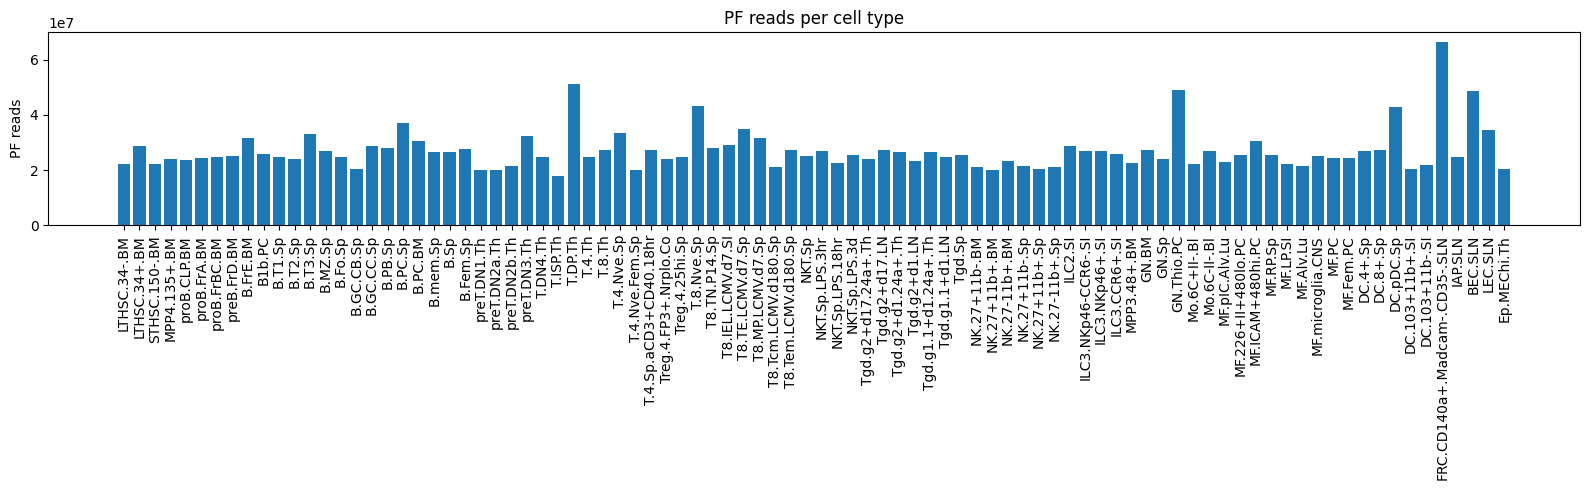

In [31]:
plt.figure(figsize=(16,5))
plt.bar(mmc1_data["CellType"], mmc1_data["PF.reads"])
plt.xticks(rotation=90)
plt.ylabel("PF reads")
plt.title("PF reads per cell type")
plt.tight_layout()
plt.show()

nach dem paper wurde ein threshold von 2,470,102. Minimum bei 16 Millionen: deutlich drüber

**Missing values**

In [32]:
#number of missing data points per column
missing_values_count_mmc1 = mmc1_data.isnull().sum()
missing_values_count_mmc1[missing_values_count_mmc1 > 0] #just show columes where data is missing

Replicate.cor    5
dtype: int64

In [33]:
mmc1_data[mmc1_data["Replicate.cor"].isnull()]

,SampleName,CellType,ImmGenLab,Lineage,CellFamily,Organ,SortingMarkers,InputCellNumber,PF.reads,%chrM.mapped,Paired.read.after.removing.PCR.duplication,%fragment.1Kb_TSS,Replicate.cor
0,LTHSC.34-.BM#1,LTHSC.34-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34-,677,22287984,4.58,2470102,10.60,NaN
1,LTHSC.34+.BM#1,LTHSC.34+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34+,2483,28588536,3.17,7675501,7.70,NaN
2,STHSC.150-.BM#1,STHSC.150-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150-CD48-,3660,22170346,3.25,6060045,11.13,NaN
3,MPP4.135+.BM#1,MPP4.135+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135+,10000,24003590,13.83,6128252,18.96,NaN
127,MPP3.48+.BM#1,MPP3.48+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150-CD48+,10000,22469306,3.91,7429716,9.25,NaN


**Missing values in mmc1**

<br> Replicate correlation einzige colume mit missing Werte: 5 missing Werte. <br>

Im paper wurde: <br>
<i><small> "(3) Concordance between the two biological replicates. We
selected, for each cell-type, a subset of OCRs in which the raw edge counts were >= 10 in at
least one replicate, which was used to compute a Pearson correlation between the two
replicates. The Pearson coefficient is sensitive to the total number of reads (as evidenced by
the B cell pilot, Fig. S1B left). The samples retained for the analysis exhibited comparable
inter replicates correlations to the trend estimated from B cell pilots (green line, Fig. S1B
right)." </i></small>

Das bedeutet:<br>
es misst die Reproduzierbarkeit des ATAC-seq accesssibility profiles zwischen biologischen Repliakte des selben Zelltypes (Sample #1 oder #2)<br>
**Hohe Werte:** beide replicate ähnlcihe accesibility Muster über OCR --> gute Datenqualität<br>
**Keine Wertte:** einach nur ein Sample vorhanden oder keine Repliakte - Correlation...

**mmc1 Analyse metrics columes** 

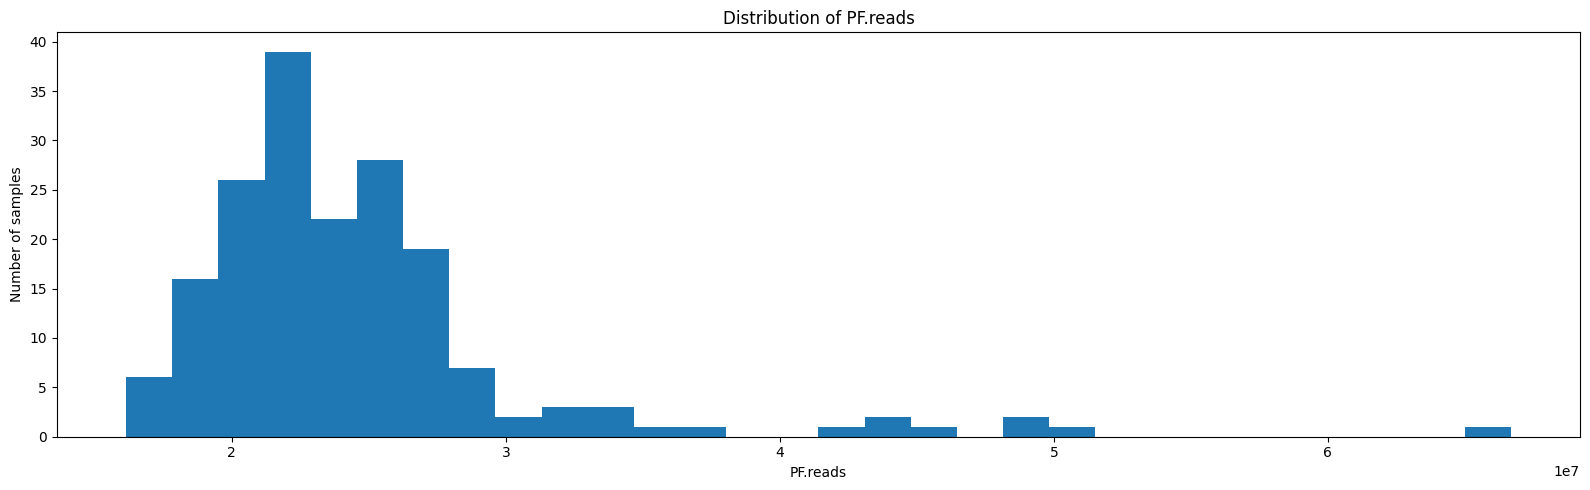

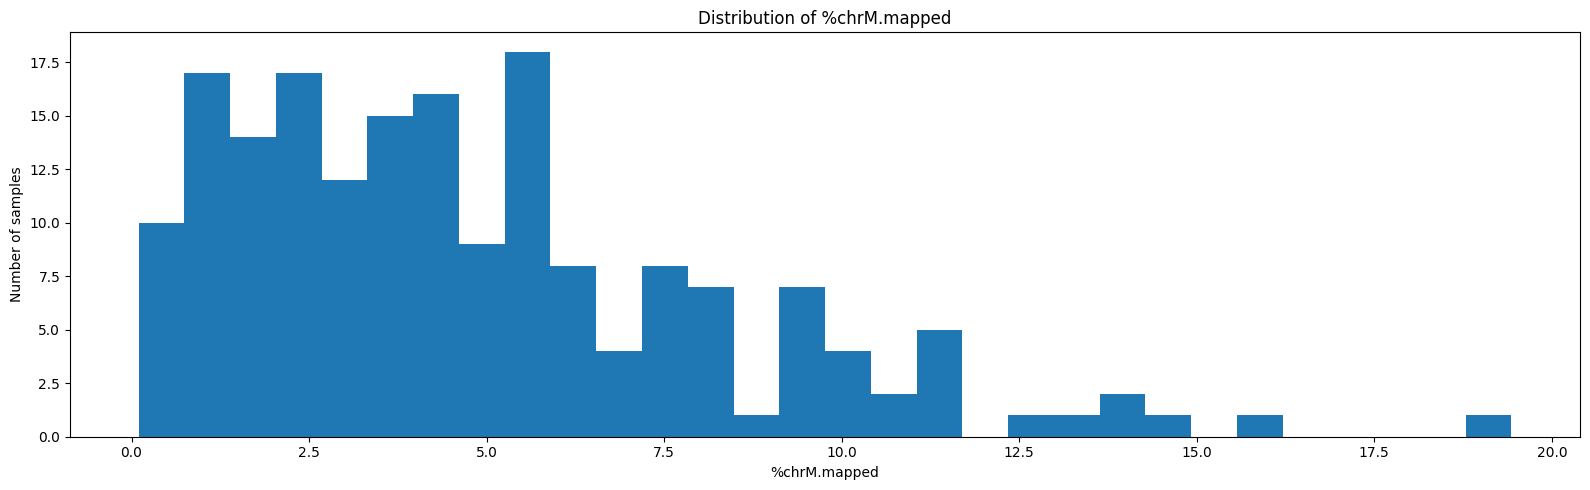

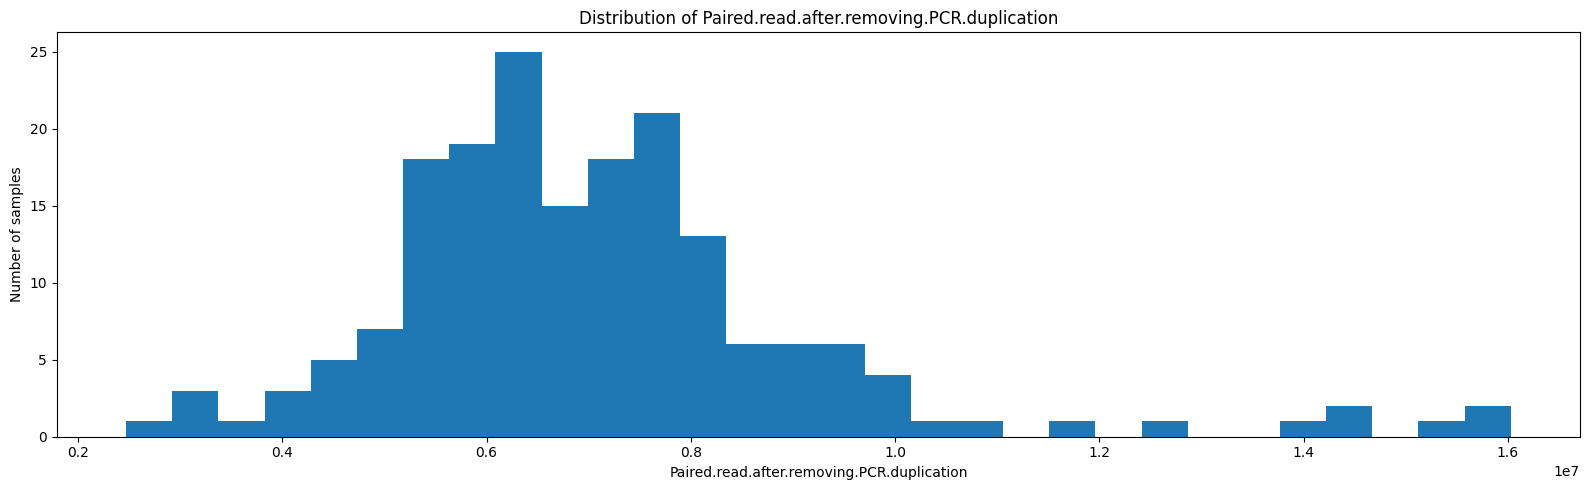

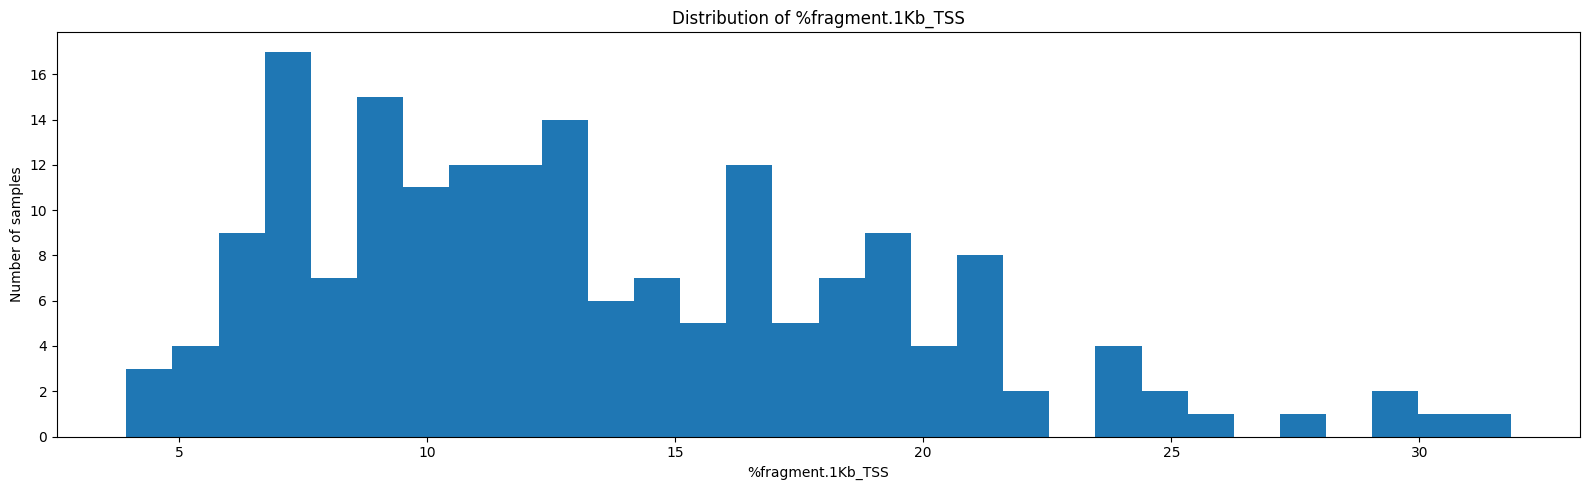

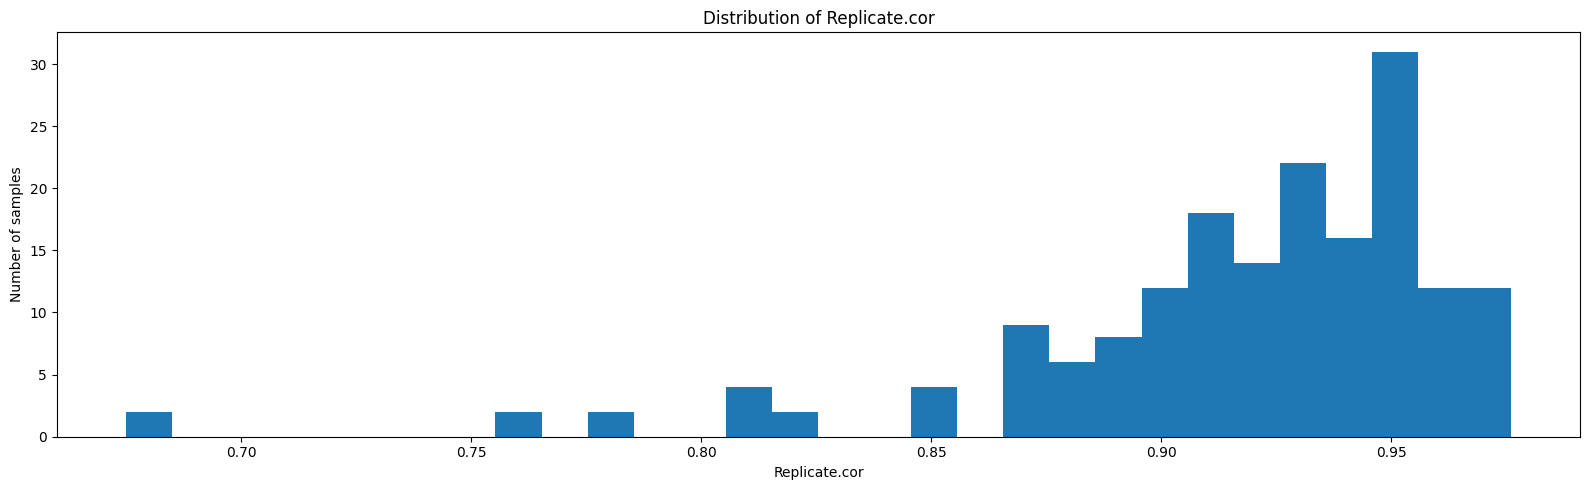

In [34]:
mmc1_parameter = [
    "PF.reads",
    "%chrM.mapped",
    "Paired.read.after.removing.PCR.duplication",
    "%fragment.1Kb_TSS",
    "Replicate.cor"
]

for parameter in mmc1_parameter:
    plt.figure(figsize=(16,5))
    plt.hist(mmc1_data[parameter].dropna(), bins=30)
    plt.xlabel(parameter)
    plt.ylabel("Number of samples")
    plt.title(f"Distribution of {parameter}" ) # f-String: variable in geschweiften Klammern, setzt Werte automatisch ein
    plt.tight_layout()
    plt.show()



Nach dem Paper verwendeten QC-Schwellenwerte sehen die Verteilungen der QC-samples relativ gut aus

# 1.2 Signal Variability Across CREs


### 1.2.1 Should any peaks be filtered out due to insufficient signal?

Wie viel ATAC-Signal hat dieser Peak insgesamt über alle verwendeten Zelltypen/Samples?

In [43]:
annotation_cols = [
    "ImmGenATAC1219.peakID",
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATAC_signal = ATAC_pfiltered.drop(columns=annotation_cols)
peak_total = ATAC_signal.sum(axis=1)
peak_total.describe()

count    362330.000000
mean        458.318951
std         887.305913
min          24.420000
25%         137.700000
50%         207.290000
75%         407.510000
max       62693.390000
dtype: float64

Annotations-Spalten entfernen<br>
Gesamtsignal pro Peak berechnen (Peak 1: Signal in Sample1 + Sample2 ...; Peak 2: Signal in Sample1 + Sample2 ... )<br>

<h3>Low-Signal Peaks prüfen</h3>

In [44]:
low_signal_peaks = peak_total == 0

print("Total CREs:", ATAC_signal.shape[0])
print("Zero-signal CREs:", low_signal_peaks.sum())
print("Percent zero-signal CREs:", low_signal_peaks.mean() * 100)

Total CREs: 362330
Zero-signal CREs: 0
Percent zero-signal CREs: 0.0


In [45]:
nonzero_peak = (ATAC_signal > 0).sum(axis=1) # > Vergleichsoperator --> gibt boolean zurück
nonzero_peak.describe()

count    362330.0
mean         90.0
std           0.0
min          90.0
25%          90.0
50%          90.0
75%          90.0
max          90.0
dtype: float64

kein peak hat Gesamtsignal 0, jeder Peak hat in allen 90 Samples ein Signal > 0

In [38]:
peak_total_signal = ATAC_signal.sum(axis=1)
peak_total_signal.describe()

count    362330.000000
mean        458.318951
std         887.305913
min          24.420000
25%         137.700000
50%         207.290000
75%         407.510000
max       62693.390000
dtype: float64

(array([1.0000e+00, 0.0000e+00, 2.0000e+00, 6.0000e+00, 8.0000e+00,
        2.0000e+01, 2.3000e+01, 5.7000e+01, 1.2800e+02, 2.1900e+02,
        4.3500e+02, 8.4000e+02, 1.4250e+03, 2.3650e+03, 3.6430e+03,
        5.6470e+03, 7.6470e+03, 1.0412e+04, 1.2624e+04, 1.4898e+04,
        1.7025e+04, 1.8141e+04, 1.8766e+04, 1.8252e+04, 1.7544e+04,
        1.6586e+04, 1.5476e+04, 1.4234e+04, 1.2741e+04, 1.1939e+04,
        1.0856e+04, 1.0098e+04, 9.2670e+03, 8.4030e+03, 7.9060e+03,
        7.4310e+03, 7.0310e+03, 6.3330e+03, 6.1450e+03, 5.6660e+03,
        5.2140e+03, 4.9440e+03, 4.5460e+03, 4.2320e+03, 3.9770e+03,
        3.6300e+03, 3.3000e+03, 3.0600e+03, 2.8740e+03, 2.5800e+03,
        2.3300e+03, 2.0980e+03, 1.8910e+03, 1.6970e+03, 1.5480e+03,
        1.3260e+03, 1.3010e+03, 1.1760e+03, 1.1100e+03, 1.0230e+03,
        9.4300e+02, 8.2500e+02, 7.3200e+02, 6.5600e+02, 6.1700e+02,
        5.8400e+02, 5.7000e+02, 5.2100e+02, 4.2900e+02, 3.8600e+02,
        3.3800e+02, 3.0800e+02, 2.7000e+02, 2.36

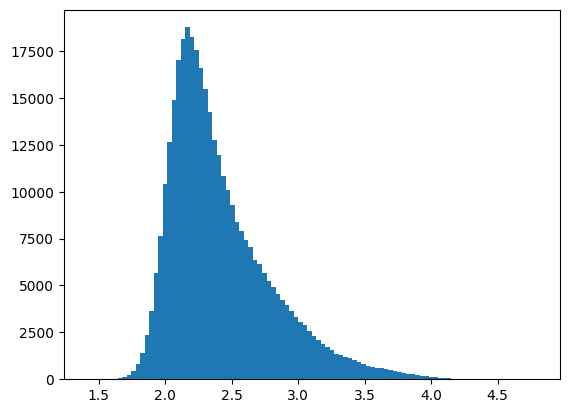

In [39]:
plt.hist(np.log10(peak_total_signal + 1), bins=100)

<h3>Mittelwertfilter </h3>  </p> Mittelwertfilter anwenden amcht kein Sinn, weil haben schon gefiltert macht kein zusätzlich Sinn noch anhand Mittelwert Werte zu entfernen
<br>Filter über niedrigen Mittelwert --> aber kann biologisch interessante sein, da sehr zelltypspezifische Peaks entfernt werden

### <p style="color: pink;"> Should any peaks be filtered out due to insufficient signal?: Summary</p>

The data come from a prefiltered and systematically analyzed OCR set. As described in the paper by Yoshida et al., the OCRs were sorted out, quantified, and normalized, thereby filtering out blacklisted genomic regions and chromosome homologous regions, thus removing possible artifacts. <br>
Also, when looking at the QC data (mmc1 data), the samples show sufficient quality, so no additional broad filtering of peaks due to insufficient signal was necessary. <br>
Additionaly all data with a p value under 0.05 (5%) were removed, setting a threshold for unreliable data and removing possible OCRs caused by background noise. <br>
Checking the minimum ATAC signal across the OCR, there were no peaks that had a signal of zero. There was no evidence for complet abscent signals and low signal peaks will be needed for analyzing the accesibility

# 1.4 CRE Classification

<h3> Can CREs be grouped into distinct classes based on signal level and cross-cell variability? Within all cell types or lineage specific? </h3>

## CRE Classification for Tgd

### Preparing Dataset

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

ATAC_seq = pd.read_csv('data/ATAC_pfiltered.csv')

ATAC_seq_gd_path = Path('data') / 'ATAC_seq_gd.csv'
ATAC_seq_gd = pd.read_csv(ATAC_seq_gd_path)
ATAC_seq_gd.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,MPP4.135+.BM,preT.DN1.Th,...,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,0.11,0.40,...,0.11,0.10,0.35,0.11,0.76,0.53,1.46,0.11,0.12,0.86
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.11,0.46,...,0.47,0.10,0.58,0.11,0.29,0.53,0.51,0.11,0.70,0.13
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.11,0.77,...,1.34,1.69,0.34,1.39,1.58,3.16,0.51,0.99,0.12,0.73
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,1.58,0.77,...,0.47,1.02,0.10,1.33,0.10,1.48,0.15,0.11,1.26,0.73
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.11,0.40,...,0.47,0.10,0.58,1.33,1.27,1.11,0.51,2.86,0.70,0.73


In [47]:
annotation_cols = [
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATAC_signal_Tgd = ATAC_seq_gd.drop(columns=annotation_cols)
ATAC_signal_Tgd.shape

(362330, 14)

In [48]:
annotation_col = [
    "ImmGenATAC1219.peakID"	
] 
    

ATAC_signal_Tgd_numeric = ATAC_signal_Tgd.drop(columns=annotation_col)
ATAC_signal_Tgd_numeric.shape


(362330, 13)

### Clustering of Peaks (CREs) based on Tgd celltypes

<h3>Calculating mean and variance</h3>

In [53]:
peak_mean_Tgd = ATAC_signal_Tgd_numeric.mean(axis=1) # Mittelwert über alle Tgd-Zelltypen für jeden peak

peak_std_Tgd = ATAC_signal_Tgd_numeric.std(axis=1) # Standardabweichung über alle Tgd-Zelltypen für jeden peak

peak_var_Tgd = ATAC_signal_Tgd_numeric.var(axis=1) # Varianz über alle Tgd-Zelltypen für jeden peak

#varianz und std sind redundant --> weiter mit Varianz
cre_parameter = pd.DataFrame(
    {"mean_signal": peak_mean_Tgd, "var": peak_var_Tgd})

cre_parameter.index = ATAC_signal_Tgd["ImmGenATAC1219.peakID"]
cre_parameter.head()

,mean_signal,var
ImmGenATAC1219.peakID,,
ImmGenATAC1219.peak_3,0.445385,0.174927
ImmGenATAC1219.peak_4,0.323846,0.049659
ImmGenATAC1219.peak_5,1.043846,0.676209
ImmGenATAC1219.peak_6,0.759231,0.298691
ImmGenATAC1219.peak_7,0.846923,0.516406


<h3> kmeans clustering </h3>

In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
import seaborn as sns

#Spaltenweise z-transformation
X_z = StandardScaler().fit_transform(cre_parameter)

silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42,  n_init=20)
    labels = kmeans.fit_predict(X_z)
    score = silhouette_score(X_z, labels, sample_size=10000, random_state=42)    
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)] #index mit größten Wert zurücl
print(f"\nBeste Clusteranzahl laut Silhouette-Score: k={best_k}")

k=2: silhouette score = 0.8932
k=3: silhouette score = 0.8527
k=4: silhouette score = 0.8290
k=5: silhouette score = 0.8192
k=6: silhouette score = 0.7548
k=7: silhouette score = 0.7635
k=8: silhouette score = 0.7071
k=9: silhouette score = 0.7152

Beste Clusteranzahl laut Silhouette-Score: k=2


Plot of silhouette score for KMeans. (Silouhette  analysis mit schönem diagramm nichr funktioniert, weil es zu viele Daten sind)

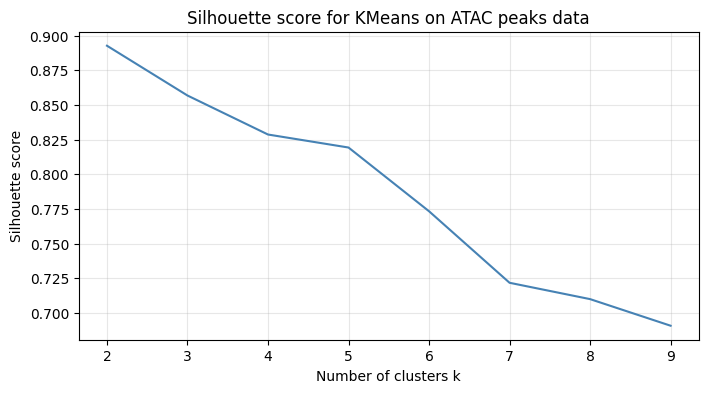

In [65]:
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on ATAC peaks data")
plt.grid(True, alpha=0.3)
plt.show()

<h3> Selecting the number of clusters and vizualizing </h3>

In [67]:
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_z)
cre_parameter['cluster'] = labels

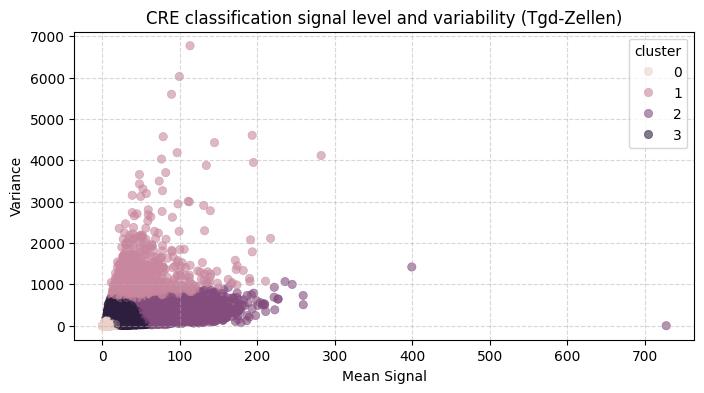

In [68]:
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=cre_parameter, 
    x="mean_signal", 
    y="var", 
    hue="cluster", 
    palette= sns.cubehelix_palette(as_cmap=True),  # Schöne, deutliche Farben für die Klassen
    alpha=0.6,
    edgecolor=None
)

plt.xlabel("Mean Signal")
plt.ylabel("Variance")
plt.title("CRE classification signal level and variability (Tgd-Zellen)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [69]:
cre_parameter.groupby('cluster')[['mean_signal','var']].mean()

,mean_signal,var
cluster,,
0,2.950395,6.600423
1,47.784021,1095.376006
2,78.615706,284.747612
3,24.103514,144.105627


<p>Cluster von k=4 gewählt. Es wurden k=2-5 alle ausprobiert und 4 war am logischten. Ob biologisch sinnvollere Unterteilung der CREs nach Signalniveau und Variabilität. k=5 würde nur noch das mittlere Cluster weiter unterteilen</p> 
Cluster 0: sehr niedrigen Mittelwert und Varianz. --> meist geschlossene CREs, variieren (335344.0 Werte)<br>
Cluster 3: niedrigen Mittelwert und mittelniedrige Varianz. --> schwach aktive CREs (22328.0) <br>
Cluster 2: hoher Mittelwert und hohe Varianz --> stark aktive CREs (3593.0)<br>
Cluster 1: sehr hohen Mittelwert und Varianz --> sehr stark aktive CREs (1065.0)<br>

In [70]:
cre_parameter.groupby('cluster')[['mean_signal','var']].var()

,mean_signal,var
cluster,,
0,8.637740,179.476113
1,1011.435692,357918.264566
2,955.319982,26312.614766
3,107.190215,12104.448146


In [71]:
cre_parameter.groupby('cluster')[['mean_signal', 'var']].describe()

mean_signal                                                         \
              count       mean        std        min        25%        50%   
cluster                                                                      
0          335344.0   2.950395   2.939003   0.122308   1.050000   1.801538   
1            1065.0  47.784021  31.803077  11.444615  27.388462  38.027692   
2            3593.0  78.615706  30.908251  36.566923  58.936923  69.630769   
3           22328.0  24.103514  10.353271   4.530000  16.725192  21.755000   

                                     var                                       \
               75%         max     count         mean         std         min   
cluster                                                                         
0         3.663077   19.559231  335344.0     6.600423   13.396870    0.001036   
1        56.181538  282.133077    1065.0  1095.376006  598.262705  630.890064   
2        89.642308  727.420000    3593.0   284.747612  162.211636    0.000000   
3        30.036154   58.420769   22328.0   144.105627  110.020217    6.941797   

                                                           
                25%         50%          75%          max  
cluster                                                    
0          0.619523    1.622886     5.682626   163.624803  
1        757.282823  905.862876  1184.707124  6769.374424  
2        161.349926  247.787659   380.301927  1421.003610  
3         67.165475  110.955406   183.069428   648.230000

<h3> Boxplot pro Cluster nach Mittelwert </h3>

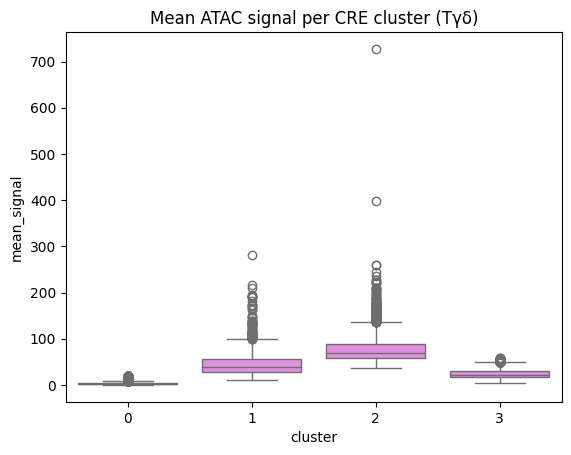

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=cre_parameter, x='cluster', y='mean_signal', color='violet')
plt.title('Mean ATAC signal per CRE cluster (Tγδ)')
plt.show()

<h3> Boxplot pro Cluster nach Varianz </h3>

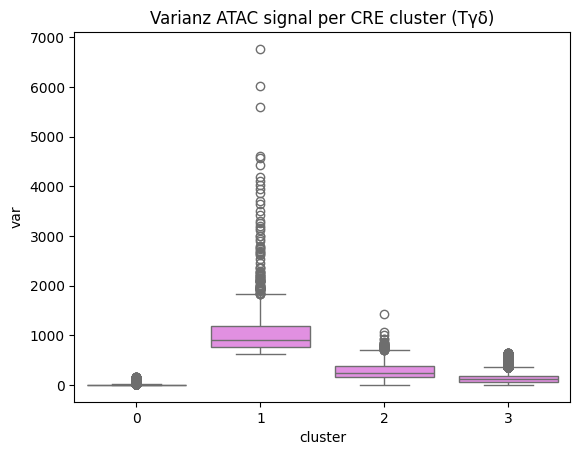

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=cre_parameter, x='cluster', y='var', color='violet')
plt.title('Varianz ATAC signal per CRE cluster (Tγδ)')
plt.show()

vllt noch mal UMAP clustering versuchen?

#### heatmap of average accessibility per Tγδ sample for each cluster

In [74]:
ATAC_signal_Tgd_numeric.head()

,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,0.11,0.40,0.77,0.11,0.10,0.35,0.11,0.76,0.53,1.46,0.11,0.12,0.86
1,0.11,0.46,0.11,0.47,0.10,0.58,0.11,0.29,0.53,0.51,0.11,0.70,0.13
2,0.11,0.77,0.84,1.34,1.69,0.34,1.39,1.58,3.16,0.51,0.99,0.12,0.73
3,1.58,0.77,0.77,0.47,1.02,0.10,1.33,0.10,1.48,0.15,0.11,1.26,0.73
4,0.11,0.40,0.84,0.47,0.10,0.58,1.33,1.27,1.11,0.51,2.86,0.70,0.73


In [78]:
ATAC_signal_Tgd_numeric = ATAC_signal_Tgd.set_index('ImmGenATAC1219.peakID') #ImmGenATAC1219.peakID als index so das cluster_parameter und ATAC daten gleichen index haben
ATAC_signal_Tgd_numeric_cluster = ATAC_signal_Tgd_numeric.copy()
ATAC_signal_Tgd_numeric_cluster['cluster'] = cre_parameter['cluster'] #neue splate ATAC daten mit clustern von Cre parameter übernommen

ATAC_signal_Tgd_numeric_cluster.head()

,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN,cluster
ImmGenATAC1219.peakID,,,,,,,,,,,,,,
ImmGenATAC1219.peak_3,0.11,0.40,0.77,0.11,0.10,0.35,0.11,0.76,0.53,1.46,0.11,0.12,0.86,0
ImmGenATAC1219.peak_4,0.11,0.46,0.11,0.47,0.10,0.58,0.11,0.29,0.53,0.51,0.11,0.70,0.13,0
ImmGenATAC1219.peak_5,0.11,0.77,0.84,1.34,1.69,0.34,1.39,1.58,3.16,0.51,0.99,0.12,0.73,0
ImmGenATAC1219.peak_6,1.58,0.77,0.77,0.47,1.02,0.10,1.33,0.10,1.48,0.15,0.11,1.26,0.73,0
ImmGenATAC1219.peak_7,0.11,0.40,0.84,0.47,0.10,0.58,1.33,1.27,1.11,0.51,2.86,0.70,0.73,0


In [79]:
#groupby cluster
cluster_sample_mean = (
    ATAC_signal_Tgd_numeric_cluster
    .groupby('cluster')
    .mean()
)
cluster_sample_mean.head()

,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
cluster,,,,,,,,,,,,,
0,3.203880,3.077105,3.022833,2.963649,2.970361,2.982815,2.960293,2.890313,2.908988,2.913996,2.840997,2.827425,2.792482
1,57.904638,60.100347,60.771465,52.966338,44.931221,35.725681,45.908441,45.390930,46.418535,39.474357,42.281202,44.131221,45.187897
2,72.950596,76.515825,77.327370,78.618505,79.006735,79.869438,79.097286,80.630810,80.649004,81.190409,80.863270,79.908839,75.376084
3,23.339158,24.336383,24.634558,24.829462,24.322645,24.094394,24.344642,24.220262,24.461671,24.507286,24.053106,24.164920,22.037195


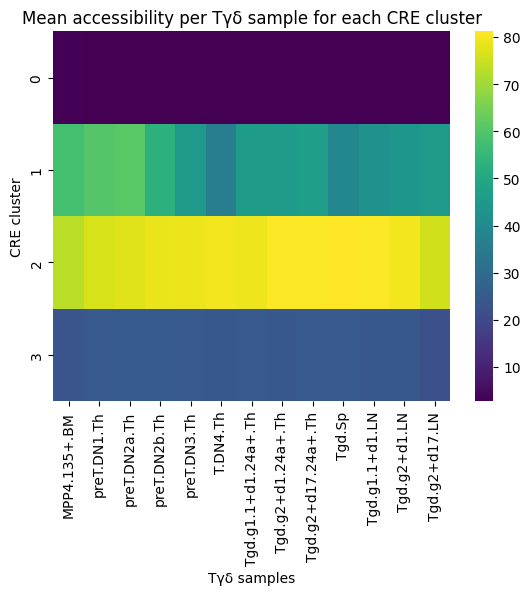

In [80]:
#Heatmap zeichenn

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cluster_sample_mean, #Zeilen --> x-Acgse, Spalten --> y-Achse, cluster spalte index nicht mitgenommen
    cmap="viridis"
)

plt.title('Mean accessibility per Tγδ sample for each CRE cluster')
plt.xlabel('Tγδ samples')
plt.ylabel('CRE cluster')
plt.show()

## CRE Classification for all celltypes

<h3> Can CREs be grouped into distinct classes based on signal level and cross-cell variability? Within all cell types or lineage specific? </h3>

### Preparing Dataset 

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

ATAC_data.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_1,chr1,3020786,0.00,0.56,NaN,NaN,NaN,0.41,0.71,...,0.10,0.10,3.19,1.37,0.52,1.27,0.10,0.57,3.27,1.41
1,ImmGenATAC1219.peak_2,chr1,3087226,0.00,0.50,NaN,NaN,NaN,0.41,1.64,...,1.70,0.10,1.41,0.47,0.11,0.92,0.98,2.16,2.34,0.94
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50


In [82]:
annotation_cols = [
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATAC_signal_all = ATAC_data.drop(columns=annotation_cols)
ATAC_signal_all.head()

,ImmGenATAC1219.peakID,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,preB.FrD.BM,B.FrE.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_1,0.41,0.71,0.90,0.11,1.94,0.10,0.11,1.69,0.57,...,0.10,0.10,3.19,1.37,0.52,1.27,0.10,0.57,3.27,1.41
1,ImmGenATAC1219.peak_2,0.41,1.64,0.90,0.83,0.47,0.34,0.82,0.13,0.11,...,1.70,0.10,1.41,0.47,0.11,0.92,0.98,2.16,2.34,0.94
2,ImmGenATAC1219.peak_3,2.36,0.10,0.90,0.11,0.47,0.10,0.50,1.17,0.32,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,0.41,0.10,0.11,0.11,0.79,0.40,0.50,2.23,0.80,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,0.41,0.10,0.11,0.11,0.47,0.34,1.78,1.17,0.32,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50


In [83]:
annotation_col = [
    "ImmGenATAC1219.peakID"	
] 
    

ATAC_signal_all_numeric = ATAC_signal_all.drop(columns=annotation_col)
ATAC_signal_all_numeric.shape

(512595, 90)

### Clustering of Peaks (CREs) based on all celltypes

<h3>Calculating mean and variance</h3>

In [84]:
peak_mean_all = ATAC_signal_all_numeric.mean(axis=1) # Mittelwert über alle Tgd-Zelltypen für jeden peak

peak_std_all = ATAC_signal_all_numeric.std(axis=1) # Standardabweichung über alle Tgd-Zelltypen für jeden peak

peak_var_all = ATAC_signal_all_numeric.var(axis=1) # Varianz über alle Tgd-Zelltypen für jeden peak

#varianz und std sind redundant
cre_parameter_all = pd.DataFrame(
    {"mean_signal": peak_mean_all, "var": peak_var_all})

cre_parameter_all.index = ATAC_signal_all["ImmGenATAC1219.peakID"]
cre_parameter_all.head()

,mean_signal,var
ImmGenATAC1219.peakID,,
ImmGenATAC1219.peak_1,1.053556,1.013886
ImmGenATAC1219.peak_2,0.929000,0.748142
ImmGenATAC1219.peak_3,1.521000,45.111153
ImmGenATAC1219.peak_4,0.874556,2.352263
ImmGenATAC1219.peak_5,0.882111,0.666815


<h3> kmeans clustering </h3>

In [85]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
import seaborn as sns

#Spaltenweise z-trasnformation
X_z_all = StandardScaler().fit_transform(cre_parameter_all)

silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_z_all)
    score = silhouette_score(X_z_all, labels, sample_size=10000, random_state=42)    
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nBeste Clusteranzahl laut Silhouette-Score: k={best_k}")

k=2: silhouette score = 0.9149
k=3: silhouette score = 0.8625
k=4: silhouette score = 0.8520
k=5: silhouette score = 0.8493
k=6: silhouette score = 0.7934
k=7: silhouette score = 0.8015
k=8: silhouette score = 0.7449
k=9: silhouette score = 0.7576

Beste Clusteranzahl laut Silhouette-Score: k=2


Plot of silhouette score for KMeans. (Silouhette  analysis mit schönem diagramm nichr funktioniert, weil es zu viele Daten sind)

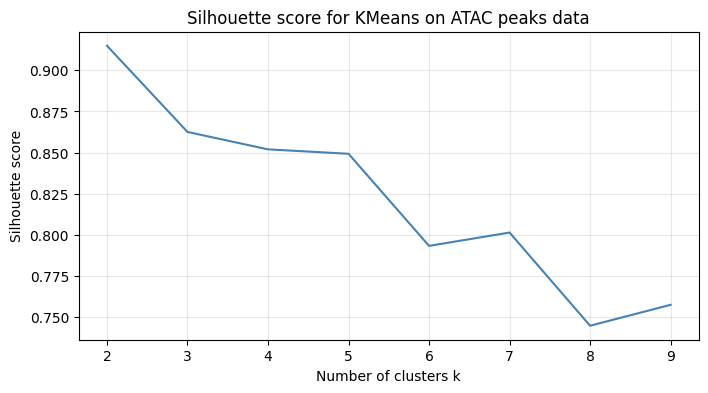

In [86]:
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on ATAC peaks data")
plt.grid(True, alpha=0.3)
plt.show()

<h3> Selecting the number of clusters and vizualizing </h3>

In [87]:
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_z_all)
cre_parameter_all['cluster'] = labels

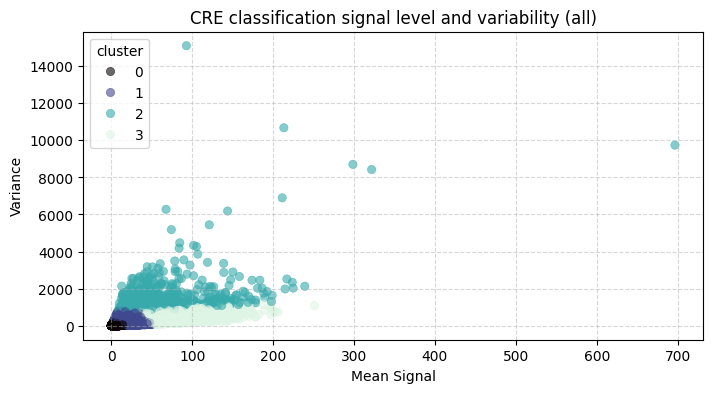

In [88]:
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=cre_parameter_all, 
    x="mean_signal", 
    y="var", 
    hue="cluster", 
    palette= sns.color_palette("mako", as_cmap=True),  # Schöne, deutliche Farben für die Klassen
    alpha=0.6,
    edgecolor=None
)

plt.xlabel("Mean Signal")
plt.ylabel("Variance")
plt.title("CRE classification signal level and variability (all)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [89]:
cre_parameter_all.groupby('cluster')[['mean_signal','var']].mean()

,mean_signal,var
cluster,,
0,2.488986,10.070729
1,19.318798,197.522807
2,51.709163,1328.330292
3,71.148158,386.414758


In [90]:
cre_parameter_all.groupby('cluster')[['mean_signal','var']].var()

,mean_signal,var
cluster,,
0,4.847990,352.974738
1,90.696953,19664.883866
2,1982.572355,786515.927359
3,646.502353,38906.942106


In [91]:
cre_parameter_all.groupby('cluster')[['mean_signal', 'var']].describe()

mean_signal                                                         \
              count       mean        std        min        25%        50%   
cluster                                                                      
0          481461.0   2.488986   2.201815   0.163333   1.244667   1.677778   
1           26130.0  19.318798   9.523495   2.520000  12.045611  17.277722   
2            1062.0  51.709163  44.526086   9.307333  26.105083  36.452833   
3            3942.0  71.148158  25.426411  33.532556  53.209222  63.498111   

                                     var                                       \
               75%         max     count         mean         std         min   
cluster                                                                         
0         2.740667   17.616000  481461.0    10.070729   18.787622    0.035946   
1        24.546361   50.916000   26130.0   197.522807  140.231537   18.291948   
2        60.066139  696.593222    1062.0  1328.330292  886.857332  781.128059   
3        82.111056  251.171333    3942.0   386.414758  197.248427   72.831904   

                                                             
                25%          50%          75%           max  
cluster                                                      
0          1.327962     2.843110     9.148326    187.763733  
1         99.588302   160.962053   247.606663    840.541302  
2        938.087290  1110.110617  1404.966814  15102.038410  
3        234.489507   338.722291   505.142406   1160.542239

<h3> Boxplot pro Cluster nach Mittelwert </h3>

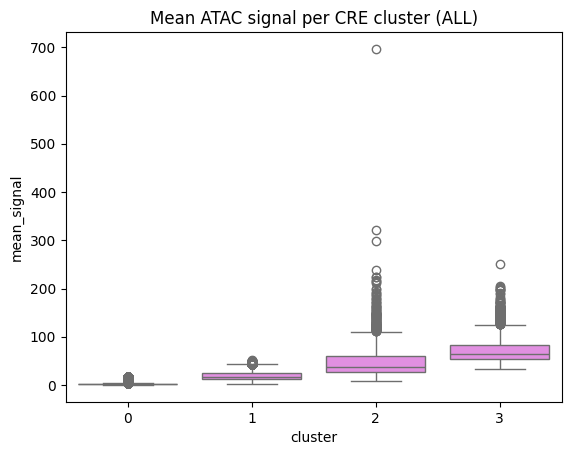

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=cre_parameter_all, x='cluster', y='mean_signal', color='violet')
plt.title('Mean ATAC signal per CRE cluster (ALL)')
plt.show()

<h3> Boxplot pro Cluster nach Varianz </h3>

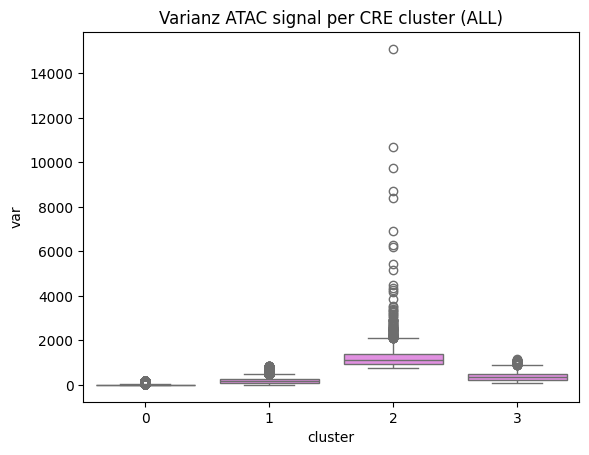

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=cre_parameter_all, x='cluster', y='var', color='violet')
plt.title('Varianz ATAC signal per CRE cluster (ALL)')
plt.show()

vllt noch mal UMAP clustering versuchen?

## Vergleiche Cluster nach Signastärke global vs lokal

In [94]:
cre_parameter_all['cluster'].value_counts(normalize=True) #normalize=True: W-keit

cluster
0    0.939262
1    0.050976
3    0.007690
2    0.002072
Name: proportion, dtype: float64

In [95]:
cre_parameter['cluster'].value_counts(normalize=True) #normalize=True: W-keit

cluster
0    0.925521
3    0.061623
2    0.009916
1    0.002939
Name: proportion, dtype: float64

Sowohl global als auch bei den cell lineages befinden sich 93% der CREs die Verteilung der Peaks über die Cluster in den schwach aktiven und wenig variablen Cluster und nur unter 1% in den hochaktiven und hochvariablen Clustern

## Summary: 1.4 CRE classification by signalstrength and variability

For CRE classification by signal strength and variability, we clustered elements based on their mean accessibility and variability across different cell types. This separated CREs in a very simple way, primarily by signal strength (low to high) and variability (constant to highly fluctuating). Thus, the clusters mainly distinguish between “closed and low signal” and “open and high signal” without clear lineage-specific patterns and are therefore of limited biological interpretability for Tγδ-specific regulation.

# 2.4 CRE–Gene Association via Regression

## How much variance in gene expression can a regression model explain per gene

Regression: wie gut kann ich Genexpression durch ATAC Peaks vorhersagen?

### Theorie

1. Linear Regression Model <br>
Assuming a linear relationship between peak accessibility ($X$) and gene expression ($Y$):

* **$Y$** = gene expression  
* **$X$** = peak accessibility  
* **Intercept $b_0$:** predicted expression of a gene when peak accessibility is 0  
* **Slope $b_1$:** how much the expression changes when accessibility increases  

$$\hat{Y}_i = b_0 + b_1 X_i$$

2. Parameter Estimation <br>
Parameters of the regression line are estimated using the least-squares method by minimizing the sum of squares of the deviations:

$$\min_{b_0, b_1} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2$$

$$b_0 = \bar{Y} - b_1 \cdot \bar{X}$$

$$b_1 = corr(X, Y) \frac{s_Y}{s_X}$$

The slope $b_1$ is calculated from the correlation coefficient and the standard deviations of $X$ and $Y$.

3. Residuals <br>
Actual value minus predicted value: 
$$e_i = Y_i - \hat{Y}_i$$

4. Baseline Comparison <br>
Comparing with a null model: Does the model explain more than just the average?

5. Analysis of Variance (SST = SSM + SSR)<br>
* **$SST$ (Total Sum of Squares):** Total variance in $Y$. Measures how much the gene expression fluctuates overall around its mean.
* **$SSM$ (Model Sum of Squares):** Variance explained by the model. The proportion of variance in gene expression that can be directly explained by peak accessibility (distance from the regression line to the mean).
* **$SSR$ (Residual Sum of Squares):** Unexplained variance. The sum of squared deviations between the actual observed values and the model's predictions.

6. Coefficient of Determination ($R^2$)<br>
Proportion of the total variance explained by the model: <br>
**How much variance in gene expression can a regression model explain per gene?**

$$R^2=\frac{SSM}{SST}$$

The model works well when as much variance as possible lies in $SSM$ and as little as possible in $SSR$ ($\text{SSR} < \text{SSM}$).

<h3>Umsetzung Python</h3>

* ein Modell auf alle Zelltypen
* ein Modell spezifisch auf Tγδ

1. Gene wählen
* Tγδ-spezifische Gene (Tilmann: 2.2: hoher Gini) 
* vllt ein paar Houskeeping Gens als kontrolle?
2. ATAC Daten für alle Zelltypen oder auf Tγδ Zellen spezifisch (je nach Modell): Peaks pro Gen auswählen?
3. Matrix und dann Regression mit z.B. Funktion aus scikit 

## Il17f

### Wie viel der IL17f-Expression können CREs erklären? Tgd-cells
--> zu wenige Zelltypen besser auf alle

#### RNA seq IL17 spezifische Gene aufrufen

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [97]:
from pathlib import Path
RNA_seq_IL17_path = Path('data') /'RNA_seq_IL17.csv'
RNA_seq_IL17 = pd.read_csv(RNA_seq_IL17_path)
RNA_seq_IL17 #head: zeigt nur erste 5 Zeilen --> trotzdem alles geladen

,Unnamed: 0,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,Il17a,1.020795,1.02126,1.021750,1.021812,1.023171,1.140409,1.024462,1.025833,1.025543,...,1.025785,1.025785,1.021812,1.022767,1.024462,1.019656,1.017884,1.019107,1.017884,1.005329
1,Il17b,1.020795,1.02126,1.021750,1.021812,1.023171,1.021346,1.024462,1.025833,1.025543,...,1.025785,1.025785,1.126600,1.022767,1.024462,1.019656,1.017884,1.040295,1.017884,1.052731
2,Il17c,1.020795,1.02126,1.021750,1.021812,1.368419,1.021346,1.024462,3.296594,1.516769,...,1.025785,1.634780,1.146294,1.147249,1.685787,1.019656,1.017884,1.443479,1.017884,1.041095
3,Il17f,1.096732,1.02126,1.206849,1.136401,1.023171,1.415983,2.791838,1.025833,2.134394,...,1.025785,1.025785,1.021812,1.147249,1.392594,1.135090,1.017884,1.040295,1.017884,1.021351


In [98]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

RNA_seq_gd_IL17 = RNA_seq_IL17[Tgd_cells]
RNA_seq_gd_IL17

,Unnamed: 0,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,Il17a,1.021812,1.022363,1.024462,1.024819,1.024482,1.026430,1.023995,1.162753,1.024819,1.023995,1.025543,1.024819,1.023995
1,Il17b,1.021812,1.022363,1.024462,1.024819,1.024482,1.026430,1.023995,1.022363,1.024819,1.023995,1.025543,1.024819,1.023995
2,Il17c,1.021812,1.022363,1.024462,1.024819,1.024482,1.026430,1.238917,1.022363,1.024819,1.515220,1.025543,1.426854,1.023995
3,Il17f,1.136401,1.022363,1.024462,1.374003,1.024482,1.683173,1.023995,1.470954,1.754676,2.094547,1.025543,3.957685,40.083782


**IL17f** hat die höchsten Expressionsdaten: Tgd.g2+d17.LN mit 40.08 <br>
wird für's Regressionsmodell verwendet 

#### ATAC seq IL17 spezifische Gene aufrufen

In [99]:
from pathlib import Path
ATAC_seq_IL17_path = Path('data') /'ATAC_seq_IL17.csv'
ATAC_seq_IL17 = pd.read_csv(ATAC_seq_IL17_path)
ATAC_seq_IL17 #head: zeigt nur erste 5 Zeilen --> trotzdem alles geladen

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_2073,chr1,20670994,0.76,1.41,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a",2.36,3.68,...,0.93,3.00,1.75,0.95,1.32,2.64,0.26,3.24,6.86,0.50
1,ImmGenATAC1219.peak_2075,chr1,20686124,0.22,9.93,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.41,0.71,...,0.44,0.78,2.16,0.89,0.52,1.85,2.00,3.24,4.33,1.03
2,ImmGenATAC1219.peak_2077,chr1,20700177,0.19,2.07,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",2.36,3.68,...,1.26,0.10,2.16,0.53,1.39,3.31,1.75,2.21,6.04,1.36
3,ImmGenATAC1219.peak_2078,chr1,20701584,0.04,1.49,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.41,0.10,...,0.44,1.93,1.32,0.47,2.92,2.15,0.98,0.14,2.17,0.93
4,ImmGenATAC1219.peak_2081,chr1,20725819,0.64,4.64,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.41,1.64,...,0.93,0.97,0.11,0.11,1.66,0.56,0.88,0.52,4.12,1.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,ImmGenATAC1219.peak_472800,chr8,122511638,0.12,2.03,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",0.41,3.68,...,1.76,1.39,0.66,1.79,0.52,9.17,1.10,1.54,1.64,1.03
221,ImmGenATAC1219.peak_472802,chr8,122517685,0.05,4.72,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",4.37,4.78,...,2.42,1.39,3.19,0.53,1.72,1.27,1.52,30.62,14.86,0.53
222,ImmGenATAC1219.peak_472803,chr8,122518322,0.07,1.56,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",0.41,6.07,...,1.70,0.29,1.32,0.89,0.51,0.11,0.88,4.81,2.29,1.43
223,ImmGenATAC1219.peak_472805,chr8,122519632,0.02,1.98,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",16.15,4.78,...,1.34,1.54,0.11,0.53,1.82,1.10,0.34,1.54,0.11,0.94


In [101]:
ATAC_seq_gd_IL17 = pd.concat([ATAC_seq_IL17[[
        "ImmGenATAC1219.peakID",
        "chrom",
        "Summit",
        "mm10.60way.phastCons_scores",
        "_-log10_bestPvalue",
        "Included.in.systematic.analysis",
        "TSS", 
        "genes.within.100Kb"
    ]],
    ATAC_seq_IL17[Tgd_cells[1:]].copy()], axis=1)
ATAC_seq_gd_IL17

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,MPP4.135+.BM,preT.DN1.Th,...,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,ImmGenATAC1219.peak_2073,chr1,20670994,0.76,1.41,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a",3.49,0.40,...,1.75,2.83,0.78,1.02,1.08,0.11,2.37,0.46,1.95,7.28
1,ImmGenATAC1219.peak_2075,chr1,20686124,0.22,9.93,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",1.58,2.09,...,0.51,0.10,1.02,2.02,1.08,2.91,4.33,2.35,4.17,56.70
2,ImmGenATAC1219.peak_2077,chr1,20700177,0.19,2.07,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.83,3.77,...,2.82,3.07,2.24,3.00,5.23,8.36,3.55,2.77,1.95,4.15
3,ImmGenATAC1219.peak_2078,chr1,20701584,0.04,1.49,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",1.58,0.40,...,0.11,0.10,2.29,0.11,0.76,1.48,1.04,3.12,0.68,2.60
4,ImmGenATAC1219.peak_2081,chr1,20725819,0.64,4.64,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.83,0.46,...,0.51,0.10,1.27,3.00,4.76,7.48,1.46,0.64,1.91,26.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,ImmGenATAC1219.peak_472800,chr8,122511638,0.12,2.03,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",0.11,0.40,...,0.87,0.61,0.35,0.11,4.83,2.62,1.82,2.20,1.95,2.21
221,ImmGenATAC1219.peak_472802,chr8,122517685,0.05,4.72,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",3.49,2.61,...,1.78,0.22,1.88,0.89,1.42,1.47,1.29,0.46,0.12,1.48
222,ImmGenATAC1219.peak_472803,chr8,122518322,0.07,1.56,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",0.11,0.46,...,0.11,1.69,3.17,0.89,0.59,3.13,1.04,2.63,0.68,0.13
223,ImmGenATAC1219.peak_472805,chr8,122519632,0.02,1.98,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",3.04,1.76,...,1.40,1.03,1.51,0.11,2.08,1.64,0.15,1.62,1.95,0.13


Filtern nach IL17f

In [102]:
annotation_cols = [
    "ImmGenATAC1219.peakID",
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]


ATAC_seq_gd_IL17f = ATAC_seq_gd_IL17[ATAC_seq_gd_IL17["genes.within.100Kb"].str.contains("Il17f")].copy() #str.contains = enthält (isin geht nicht weil viele gene in der spalte in eienr Zeile)


ATAC_seq_gd_IL17f_num = ATAC_seq_gd_IL17f.drop(annotation_cols, axis=1)

#### Regressionsmodell

Matrix erstellen: X = peaks, Y = IL17f-Expression

In [115]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

RNA_seq_gd_IL17f = RNA_seq_gd_IL17[RNA_seq_gd_IL17["Unnamed: 0"] == "Il17f"].copy() #Zeile außer IL17f entfernen
RNA_seq_gd_IL17f = RNA_seq_gd_IL17f.drop("Unnamed: 0", axis=1, errors="ignore").copy() #Spalte Unamed entfernen

#Spalten = Peaks
X = ATAC_seq_gd_IL17f_num.T
X_labels = ATAC_seq_gd_IL17f["ImmGenATAC1219.peakID"].values
# Y: IL17f-Expression

y = RNA_seq_gd_IL17f.T #Transponieren Zelltypen sind zeilen
y = y.loc[X.index] #Y wird an Zeilen X angepasst

X_scaled = StandardScaler().fit_transform(X) #Spaltenweise z-trasnformation
# Regressionamodell von scikit-learn
reg = Ridge(alpha=10.0).fit(X_scaled, y)

# Cross-Validation
scores = cross_val_score(reg, X_scaled, np.ravel(y), cv=5, scoring="r2")

print("CV R^2 pro Fold:", scores.round(3))

CV R^2 pro Fold: [ -25.431  -33.81  -286.134  -23.928   -1.283]


30 peaks aber nur 13 Zeilen --> Modell sagt Expression perfekt voraus, da man mehr Koeffizienten als Datenpunkte hat --> Modell findet perfekte gerade --> Ridge-Regression

skitlearn: 3.1. Cross-validation: evaluating estimator performance --> problem: overfitting (Modell passt sich zu perfekt an die Trainingsdaten ran) <br>

Lösung: Cross Validation:<br>
1. Die gesamten Daten werden in $K$ gleich große Teile (Folds/Blöcke) aufgeteilt (z. B. 5 Teile).<br>
2. Das Modell wird nun 5-mal hintereinander trainiert und getestet.<br>
3. In jedem Durchgang (Split) dient ein anderer Block als Testdaten (Validierungsdaten) und die restlichen 4 Blöcke als Trainingsdaten.<br>

Ergebnis: negative R^2 Werte: Modell zeigt IL17f-Expression schlechter als durch Mittelwert 
Grund: kaum Variation in den Daten --> alle Expresisonswerte bei 1 und haben auch nur 13 Zelltypen

Lösung: Modell auf alle Zelldaten anwenden

### Wie viel der IL17f-Expression können CREs erklären? Alle Zelltypen

#### RNA seq IL17 spezifische Gene aufrufen

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [105]:
from pathlib import Path
RNA_seq_IL17_path = Path('data') /'RNA_seq_IL17.csv'
RNA_seq_IL17 = pd.read_csv(RNA_seq_IL17_path)
RNA_seq_IL17 #head: zeigt nur erste 5 Zeilen --> trotzdem alles geladen

,Unnamed: 0,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,Il17a,1.020795,1.02126,1.021750,1.021812,1.023171,1.140409,1.024462,1.025833,1.025543,...,1.025785,1.025785,1.021812,1.022767,1.024462,1.019656,1.017884,1.019107,1.017884,1.005329
1,Il17b,1.020795,1.02126,1.021750,1.021812,1.023171,1.021346,1.024462,1.025833,1.025543,...,1.025785,1.025785,1.126600,1.022767,1.024462,1.019656,1.017884,1.040295,1.017884,1.052731
2,Il17c,1.020795,1.02126,1.021750,1.021812,1.368419,1.021346,1.024462,3.296594,1.516769,...,1.025785,1.634780,1.146294,1.147249,1.685787,1.019656,1.017884,1.443479,1.017884,1.041095
3,Il17f,1.096732,1.02126,1.206849,1.136401,1.023171,1.415983,2.791838,1.025833,2.134394,...,1.025785,1.025785,1.021812,1.147249,1.392594,1.135090,1.017884,1.040295,1.017884,1.021351


#### ATAC seq IL17 spezifische Gene aufrufen

In [106]:
from pathlib import Path
ATAC_seq_IL17_path = Path('data') /'ATAC_seq_IL17.csv'
ATAC_seq_IL17 = pd.read_csv(ATAC_seq_IL17_path)
ATAC_seq_IL17 #head: zeigt nur erste 5 Zeilen --> trotzdem alles geladen

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_2073,chr1,20670994,0.76,1.41,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a",2.36,3.68,...,0.93,3.00,1.75,0.95,1.32,2.64,0.26,3.24,6.86,0.50
1,ImmGenATAC1219.peak_2075,chr1,20686124,0.22,9.93,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.41,0.71,...,0.44,0.78,2.16,0.89,0.52,1.85,2.00,3.24,4.33,1.03
2,ImmGenATAC1219.peak_2077,chr1,20700177,0.19,2.07,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",2.36,3.68,...,1.26,0.10,2.16,0.53,1.39,3.31,1.75,2.21,6.04,1.36
3,ImmGenATAC1219.peak_2078,chr1,20701584,0.04,1.49,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.41,0.10,...,0.44,1.93,1.32,0.47,2.92,2.15,0.98,0.14,2.17,0.93
4,ImmGenATAC1219.peak_2081,chr1,20725819,0.64,4.64,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.41,1.64,...,0.93,0.97,0.11,0.11,1.66,0.56,0.88,0.52,4.12,1.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,ImmGenATAC1219.peak_472800,chr8,122511638,0.12,2.03,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",0.41,3.68,...,1.76,1.39,0.66,1.79,0.52,9.17,1.10,1.54,1.64,1.03
221,ImmGenATAC1219.peak_472802,chr8,122517685,0.05,4.72,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",4.37,4.78,...,2.42,1.39,3.19,0.53,1.72,1.27,1.52,30.62,14.86,0.53
222,ImmGenATAC1219.peak_472803,chr8,122518322,0.07,1.56,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",0.41,6.07,...,1.70,0.29,1.32,0.89,0.51,0.11,0.88,4.81,2.29,1.43
223,ImmGenATAC1219.peak_472805,chr8,122519632,0.02,1.98,1.0,NaN,"Il17c,Cyba,Mvd,9330133O14Rik,Gm20735,Snai3,Rnf...",16.15,4.78,...,1.34,1.54,0.11,0.53,1.82,1.10,0.34,1.54,0.11,0.94


Filtern nach IL17f

In [107]:
annotation_cols = [
    "ImmGenATAC1219.peakID",
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]


ATAC_seq_IL17f = ATAC_seq_IL17[ATAC_seq_IL17["genes.within.100Kb"].str.contains("Il17f")].copy() #str.contains = enthält (isin geht nicht weil viele gene in der spalte in eienr Zeile)


ATAC_seq_IL17f_num = ATAC_seq_IL17f.drop(annotation_cols, axis=1)

#### Regressionsmodell

Datensatz vorbereiten

In [143]:
from sklearn.preprocessing import StandardScaler

# RNA seq daten nur von IL17f und ohne Unamed Zeile
RNA_seq_IL17f = RNA_seq_IL17[RNA_seq_IL17["Unnamed: 0"] == "Il17f"].copy() #Zeile nur IL17f behalten
RNA_seq_IL17f = RNA_seq_IL17f.drop("Unnamed: 0", axis=1, errors="ignore").copy() #Spalte Unamed entfernen

#ATAC datenstz transformieren: Spalten = Peaks
X = ATAC_seq_IL17f_num.T
X_labels = ATAC_seq_IL17f["ImmGenATAC1219.peakID"].values #Speichert Peak Ids seperat als Name

# Y: IL17f-Expression
y = RNA_seq_IL17f.T #Transponieren Zelltypen sind zeilen

# nur gemeinsame Zelltypen behalten
common_cells = X.index.intersection(y.index)
X = X.loc[common_cells]
y = y.loc[common_cells]

X_scaled = StandardScaler().fit_transform(X) #Spaltenweise z-trasnformation

Lineares Regressionsmodell war zu unzuverlässig aufgrund zu hoher Kollinearität der Peaks --> Lösung mit Ridge arbeiten
<br>
<br>Lineares Regressionsmodell: Parameters of the regression line are estimated using least-square method → minimize the sum of squares of the deviations <br> denn starke Korrelation --> große Koeffizienten <br>

deswegen **Ridge Modell** verwendet, welches penalty einführt für zu große Koeffizienten --> stabiler: 
<br> $$\min_{w} ||Xw - y||^2_2 + \alpha ||w||^2_2$$
<br> least square: $$||Xw - y||^2_2$$ 
<br>penalty: $$\alpha ||w||^2_2$$ 

In [144]:
#noch keine Cross validation
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import RidgeCV

# Regressionamodell von scikit-learn
reg = Ridge(alpha=10.0).fit(X_scaled, y) # alpha ist penalty, wenn alpha = 0 keine Strafe #.fit: trainiert Modell

r2 = r2_score(y, reg.predict(X_scaled)) #r^2 lässt das Modell für dieselben Zellen expression vorhersagen
#y wird verglichen mit vorhergesagten Wert  und berechnet R^2 (wie viel Prozent der Expressionsvarianz das Modell erklärt)
print("R^2:", r2)

R^2: 0.7784502536405484


#### Visualisierung

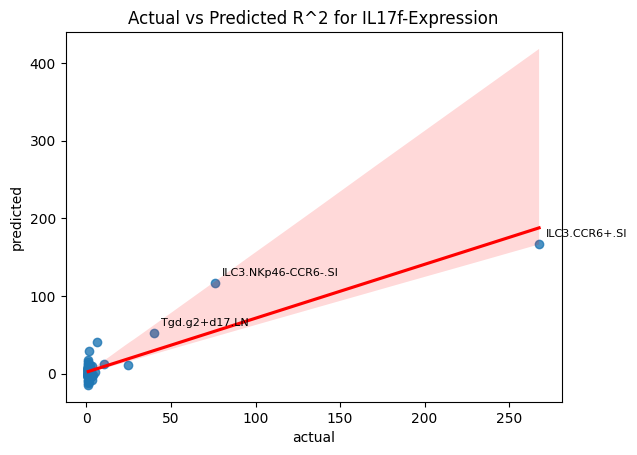

In [147]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = reg.predict(X_scaled)
y_true = np.ravel(y) #Ausgabe 1D --> verwenden für scatter plot

Reg_vis = pd.DataFrame({"actual": y_true, "predicted": y_pred}, index=X.index) #Zelltyp Namen übernehmen

sns.regplot(data=Reg_vis, x="actual", y="predicted", line_kws={"color": "red"}) 

# Name der Zellen der drei höcsten Expression
for cell in Reg_vis["actual"].nlargest(3).index:
    plt.annotate(cell, (Reg_vis.loc[cell, "actual"], Reg_vis.loc[cell, "predicted"]), 
                 fontsize=8, xytext=(5, 5), textcoords="offset points"
    )
plt.title("Actual vs Predicted R^2 for IL17f-Expression")
plt.show()

R^2 hängt nur von sehr wenigen 2-3 hoch exprimierenden Zellen ab. Die meisten Punkte sind unten links (0,0), da IL17f bei sehr vielen Zellen kaum exprimiert wird.
<br> Rosa Bereich nach rechts zeigt sehr große Unischerheit.

### Funktion für R^2: all celltypes
(+ plot predict vs actual; + residuenplot)


<h3>Datensatz vorbereiten

In [4]:
import pandas as pd
from pathlib import Path

RNA_seq_path = Path('data') / 'mmc2.csv'
RNA_seq = pd.read_csv(RNA_seq_path)

ATAC_pfiltered_path = Path('data') / 'ATAC_pfiltered.csv'
ATAC_seq = pd.read_csv(ATAC_pfiltered_path)
ATAC_seq

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362325,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,0.41,7.41,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
362326,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.36,8.79,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
362327,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
362328,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


<h3> Funktion vom Regressionsmodell (R^2) für beliebige Gene 

Lineares Regressionsmodell war zu unzuverlässig aufgrund zu hoher Kollinearität der Peaks --> Lösung mit Ridge arbeiten
<br>
<br>Lineares Regressionsmodell: Parameters of the regression line are estimated using least-square method → minimize the sum of squares of the residuen <br> denn starke Korrelation --> große Koeffizienten <br>

deswegen **Ridge Modell** verwendet, welches penalty einführt für zu große Koeffizienten --> stabiler: 
<br> w: Koeffizient, y: Zielwerte ^2_2:Fehler für jeden einzelnen Datenpunkt quadriert und dann alle aufsummiert 
<br> $$\min_{w} ||Xw - y||^2_2 + \alpha ||w||^2_2$$
<br> least square: $$||Xw - y||^2_2$$ 
<br>penalty: alpha $$\alpha ||w||^2_2$$ 

Danach immernoch gleiches Problem: Kontrollieren mit **Cross validation**
<br> <br> skitlearn: 3.1. Cross-validation: evaluating estimator performance --> problem: overfitting (Modell passt sich zu perfekt an die Trainingsdaten ran) <br>

Lösung: Cross Validation:<br>
1. Die gesamten Daten werden in $K$ gleich große Teile (Folds/Blöcke) aufgeteilt (z. B. 5 Teile).<br>
2. Das Modell wird nun 5-mal hintereinander trainiert und getestet.<br>
3. In jedem Durchgang (Split) dient ein anderer Block als Testdaten (Validierungsdaten) und die restlichen 4 Blöcke als Trainingsdaten.<br>

Ergebnis: negative R^2 Werte: Modell zeigt IL17f-Expression schlechter als durch Mittelwert 
Grund: kaum Variation in den Daten --> alle Expresisonswerte bei 1 und haben auch nur 13 Zelltypen

Modell auf alle Zelldaten anwenden etwas besser

Matrix erstellen: X = peaks, Y = Gen-Expression

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline


annotation_cols = ["ImmGenATAC1219.peakID", "chrom", "Summit",
                   "mm10.60way.phastCons_scores", "_-log10_bestPvalue",
                   "Included.in.systematic.analysis", "TSS", "genes.within.100Kb"]


def r2_gen(gen_name, plot=True, plot_residues=True):    # ohne top_k
    
    #Y: Gen-Expression
    RNA_seq_gen = RNA_seq[RNA_seq["Unnamed: 0"] == gen_name]  #Gen Namen von Unnamed in gen_name speichern
    y = RNA_seq_gen.drop("Unnamed: 0", axis=1, errors="ignore").T   #Unnamed zeile entfernen und Matrix transponiernen (Zelltypen sind Zeilen)

    # ATAC Datensatz Filtern, sodass nur peaks gewählt werden die mit Gen assoziert sind, also within 100kb
    ATAC_seq_gen = ATAC_seq[ATAC_seq["genes.within.100Kb"].str.contains(rf"\b{gen_name}\b")]

    peak_ids = ATAC_seq_gen["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_gen.drop(annotation_cols, axis=1, errors="ignore").T #ATAC datenstz transformieren: Spalten = Peaks


    #nur gemeinsame Zellen behalten behalten
    cells = X.index.intersection(y.index)
    X = X.loc[cells]
    y = y.loc[cells]

    X_scaled = StandardScaler().fit_transform(X) #Spaltenweise z-transformation

    # Ridge-Regressionamodell von scikit-learn
    # alpha ist penalty, wenn alpha = 0 keine Strafe #.fit: trainiert Modell

    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000],cv=KFold(5, shuffle=True, random_state=42))
    ridge.fit(X_scaled, y)

    #y wird verglichen mit vorhergesagten Wert und berechnet R^2 (wie viel Prozent der Expressionsvarianz das Modell erklärt)
    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # Cross-Validation mit bestem alpha
    cv = cross_val_score(
        Ridge(alpha=best_alpha),
        X_scaled,y,
        cv=KFold(5, shuffle=True, random_state=42),
        scoring="r2").mean()
    
    y_true = np.ravel(y.values) #ravel: Ausgabe 1D --> verwenden für scatter plot
    y_pred = ridge.predict(X_scaled)

    if plot:
        plt.figure(figsize=(4, 6))
        Reg_vis = pd.DataFrame({"y_actual": y_true, "y_pred": y_pred}) #DataFrame mit y und yhut
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100, color="purple")      
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=True, color="purple", line_kws={"color": "thistle"})  
        plt.title(f"Actual vs Predicted R^2 for {gen_name}\nExpression across all cells")
        plt.savefig(f"plots_for_poster/Regressionplot of{gen_name}", dpi=300, bbox_inches="tight")
        plt.show()

    if plot_residues:
        residuals = y_true - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred}) #DataFrame mit yhut und residuals
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name}-Expression across all cells")
        plt.show()  

    return r2, cv, X.shape[1], ridge, best_alpha, peak_ids,y_pred, y_true


#### R²_gen for genes with highest Gini</h3> 
<br> Predicted Values und Residuenplot dargestellt

In [3]:
for gen_name in ["Il17f"]: #, "Sox13", "Gzma", "Eomes", "Actb", "Rorc","Cd3d", "Rorc"
    r2, cv, n,_, best_alpha,_,_,_ = r2_gen(gen_name, plot_residues=False, plot=True) #variabeln brauche ich hier für nicht
    print(f"{gen_name}: R²={r2:.3f}, CV={cv:.3f}, peaks={n}, best_alpha={best_alpha}") #Anzahl der peaks über Zellen hinweg

NameError: name 'r2_gen' is not defined

sehr großes alpha und teils noch negative CV Werte. Das Modell darf nicht quantiativ interpretiert werden. Im weiteren Verlauf eher dazu verwendet Regresssions Coeffizienten relativ zu vergleichen. 

R^2 hängt nur von sehr wenigen 2-3 hoch exprimierenden Zellen ab. Die meisten Punkte sind unten links (0,0), da IL17f bei sehr vielen Zellen kaum exprimiert wird.
<br> Rosa Bereich nach rechts zeigt sehr große Unischerheit.

### Funktion für R^2: Tγδ specific cells
(+ plot predict vs actual; + residuenplot)

<h3> Datensatz vorbereiten

In [6]:
import pandas as pd
from pathlib import Path

RNA_seq_gd_path = Path('data') / 'RNA_seq_gd_anot.csv'
RNA_seq_gd = pd.read_csv(RNA_seq_gd_path)

ATAC_gd_path = Path('data') / 'ATAC_seq_gd.csv'
ATAC_seq_gd = pd.read_csv(ATAC_gd_path)

<h3> Funktion vom Regressionsmodell (R^2): Tγδ cells 

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns  
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline 


annotation_cols = ["ImmGenATAC1219.peakID", "chrom", "Summit",
                   "mm10.60way.phastCons_scores", "_-log10_bestPvalue",
                   "Included.in.systematic.analysis", "TSS", "genes.within.100Kb"]


def r2_gen_gd(gen_name_gd, plot=True, plot_residues=True):   # top_k weg
    # RNA
    RNA_seq_Tgd_gen = RNA_seq_gd[RNA_seq_gd["Unnamed: 0"] == gen_name_gd]
    y = RNA_seq_Tgd_gen.drop("Unnamed: 0", axis=1, errors="ignore").T

    # ATAC Datensatz Filtern, sodass nur peaks gewählt werden die mit Gen assoziert sind, also within 100kb
    ATAC_seq_gen = ATAC_seq_gd[ATAC_seq_gd["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name_gd}\b")]

    peak_ids = ATAC_seq_gen["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_gen.drop(annotation_cols, axis=1, errors="ignore").T #ATAC datenstz transformieren: Spalten = Peaks

    # gemeinsame Zellen angleichen
    cells = X.index.intersection(y.index)
    X = X.loc[cells]
    y = y.loc[cells]
    
    X_scaled = StandardScaler().fit_transform(X)

    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=42))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_
    
    # CV mit bestem alpha
    cv = cross_val_score(
        Ridge(alpha=best_alpha),
        X_scaled, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()

    y_actual = np.ravel(y.values)
    y_pred = ridge.predict(X_scaled)

    if plot:
        Reg_vis = pd.DataFrame({"y_actual": y_actual, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100)
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=False,
                    line_kws={"color": "red"})
        plt.title(f"Actual vs Predicted R^2 for {gen_name_gd}-Expression across Tgd cells")
        plt.show()

    if plot_residues:
        residuals = y_actual - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name_gd}-Expression across Tgd cells")
        plt.show()
    
    return r2, cv, X.shape[1], ridge, best_alpha, peak_ids

<h3> R²_gen_gd for Genes mit hohem Gini-Koeffizient bei Tgd-Zellen</h3> 
<br> Predicted Values und Residuenplot dargestellt

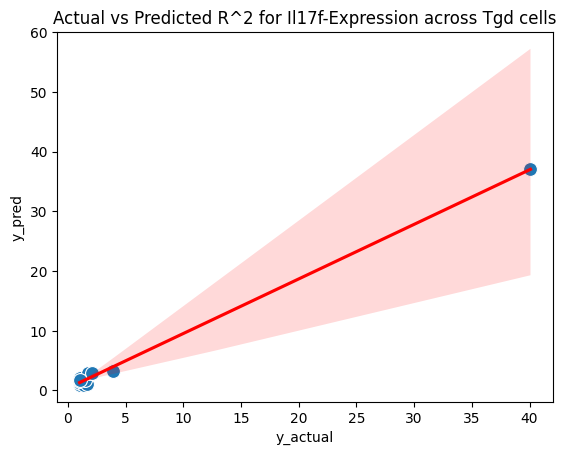

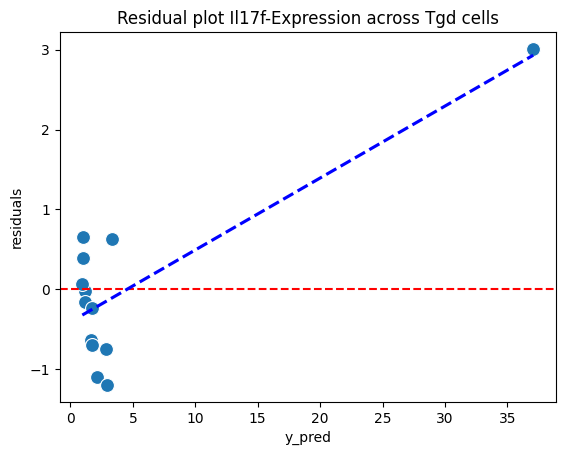

Il17f: R²=0.990, CV=-25.579, peaks=30, best_alpha=10


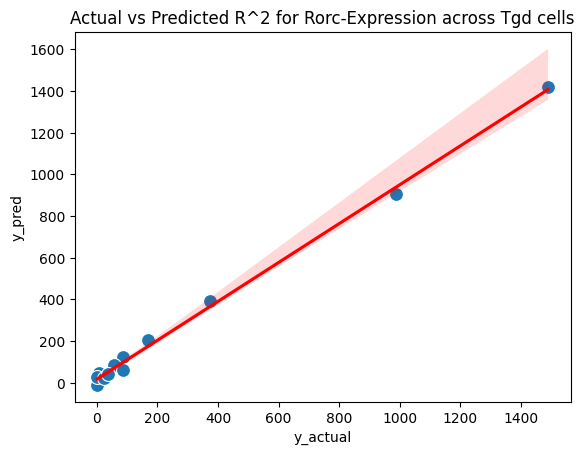

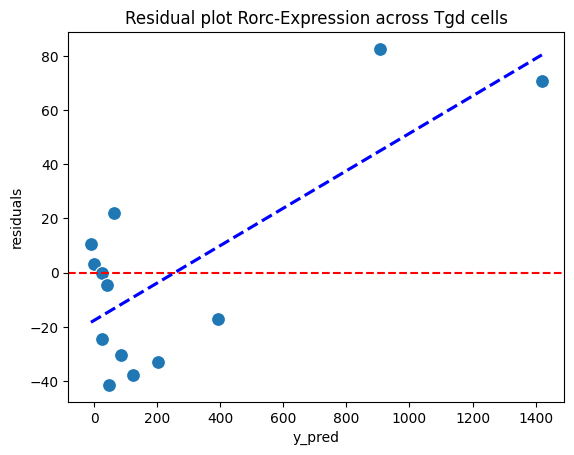

Rorc: R²=0.993, CV=-3908.351, peaks=55, best_alpha=10


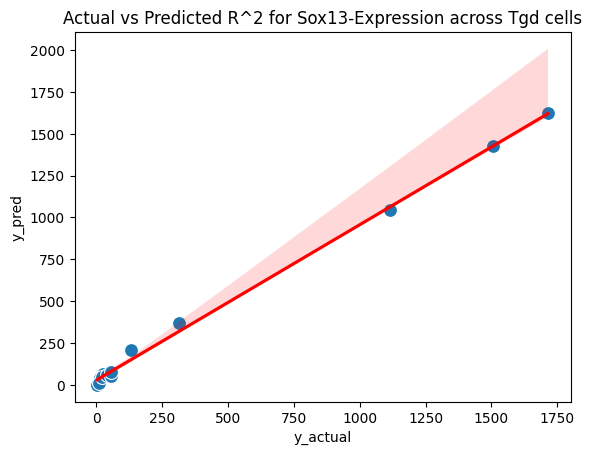

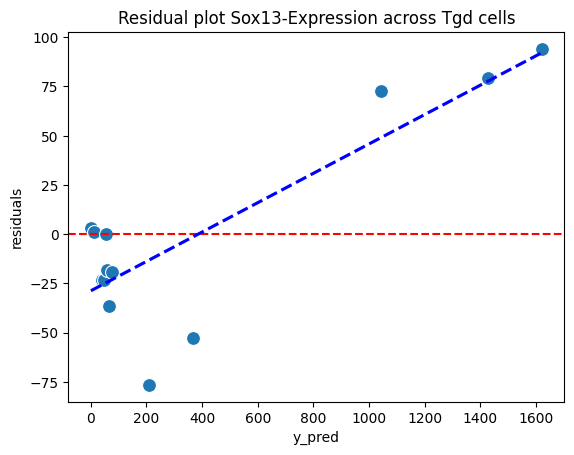

Sox13: R²=0.993, CV=-22.242, peaks=50, best_alpha=10


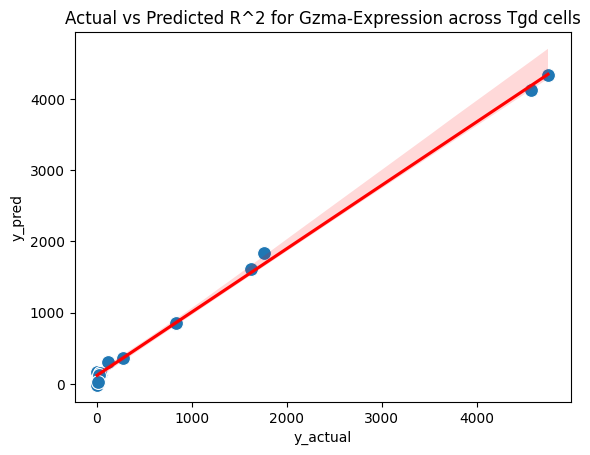

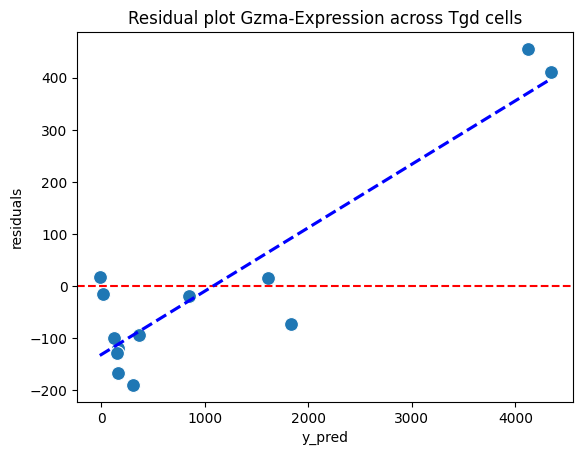

Gzma: R²=0.986, CV=-7.524, peaks=68, best_alpha=10


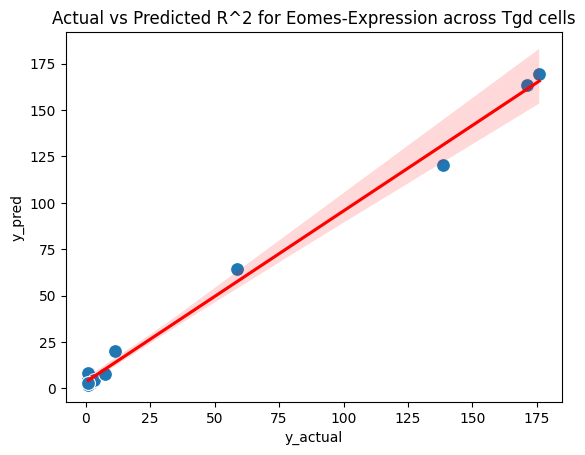

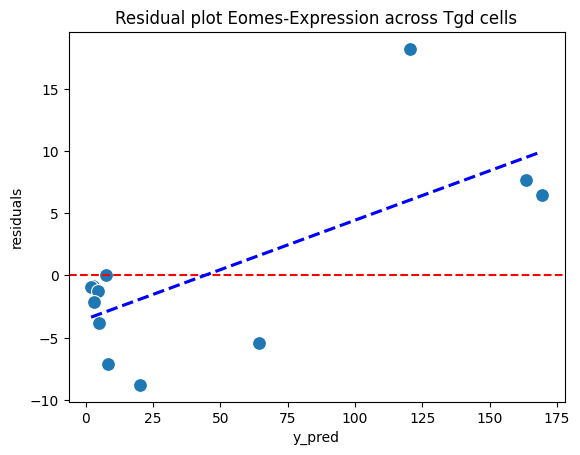

Eomes: R²=0.989, CV=-29856.268, peaks=62, best_alpha=10


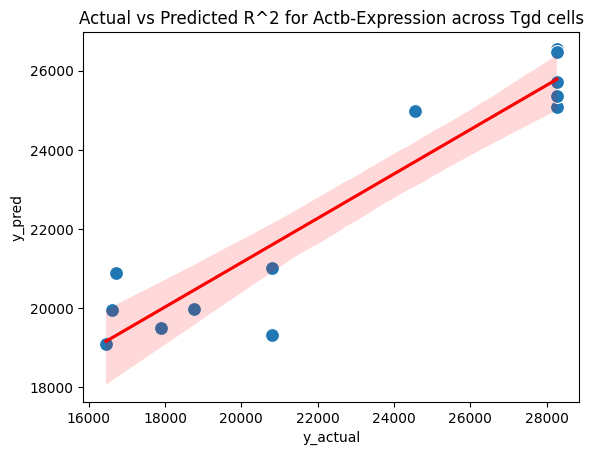

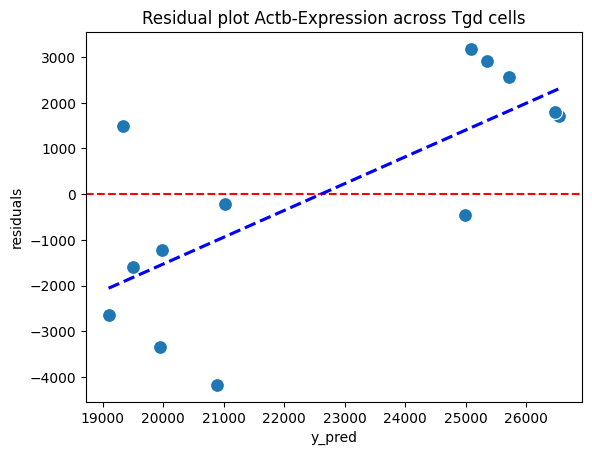

Actb: R²=0.768, CV=-0.889, peaks=85, best_alpha=100


In [8]:
for gen_name_gd in ["Il17f", "Rorc", "Sox13", "Gzma", "Eomes", "Actb"]: 
    r2, cv, n,_,best_alpha, _ = r2_gen_gd(gen_name_gd)
    print(f"{gen_name_gd}: R²={r2:.3f}, CV={cv:.3f}, peaks={n}, best_alpha={best_alpha}") #Anzahl der peaks über Zellen hinweg

## How do regression coefficients change when the model is fit on your lineage alone versus all cell types?


b: Regressionskoeffizient
$$\hat{Y}_i = b_0 + b_1 X_i$$

b1,b2...bn: ein Koeffizient pro Peak

Ansatz: 
* für jedes Gen die gleichen Peaks (gemeinsamer Peak‑Satz für all‑cells und Tγδ).
* Für jeden Peak Vorzeichen der Koeffizienten vergleichen(all_cells vs. Tgd).
* Zählen, wie viele Peaks das Vorzeichen wechseln und wie groß der Anteil ist

<h3> Vergleich der Koeffizienten‑Werte bei verschiedenen Genen: Tabelle

In [9]:
genes = "Il17f", "Arpp21",  "Eomes", "Gzma", "Kcnk1", "Rorc", "Sox13", "Actb", "Hprt", "Rplp0" ,"Cd3d"
results = []
coef_tables = {}  # speichert coef_table pro Gen

for gen in genes:
    r2_all,cv_all, n_all,reg_all,best_alpha_all,peaks_all,_,_ = r2_gen(gen, plot=False, plot_residues = False) #increasing rigid penalty to reduce overfitting
    r2_gd, _, n_gd, reg_gd, best_alpha_gd, peaks_gd = r2_gen_gd(gen, plot=False, plot_residues=False)
    
    #nur gemeinsame Peaks (verhindert Längen-Mismatch)
    coef_table = pd.DataFrame(
        {"all_cells": reg_all.coef_.ravel(),
         "Tgd":       reg_gd.coef_.ravel()},
        index=peaks_all                           # ImmGenATAC1219.peakID als Index
    )

    coef_table["gene"] = gen  # Gen-Spalte hinzufügen
    coef_tables[gen] = coef_table  # speichern

    sign_changes = (np.sign(coef_table["all_cells"]) != np.sign(coef_table["Tgd"])).sum()
    
    results.append({                            #append: erweitert Liste
        "gene": gen,
        "n_peaks": len(coef_table),
        "sign_changes": sign_changes,
        "percent_sign_changes": 100 * sign_changes / len(coef_table)
        })



coef_genes_compare = pd.DataFrame(results)
coef_genes_compare

,gene,n_peaks,sign_changes,percent_sign_changes
0,Il17f,30,11,36.666667
1,Arpp21,56,15,26.785714
2,Eomes,62,25,40.322581
3,Gzma,68,27,39.705882
4,Kcnk1,33,8,24.242424
5,Rorc,55,18,32.727273
6,Sox13,50,10,20.000000
7,Actb,85,28,32.941176
8,Hprt,36,7,19.444444
9,Rplp0,78,27,34.615385


Houskeeping genes haben ähnliche Prozentwerte

#### Scatterplot
für ausgewählte Gene: Rorc, Gzma, Eomes, Actb_all
<br><br>

**Welche Peaks werden im Tgd Modell stärker oder schwächer gewichtet als im all cells Moell, und gibt es Vorzeichenwechsel?**

X-Achse: Regressionskoeffizient all cells<br>
Y-Achse: Regressionskoeffizient Tgd Modell.

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def scattplot_coef(gen): 
    coef_table = coef_tables[gen].copy()
    
    coef_table["sign_changes"] = (np.sign(coef_table["all_cells"]) != np.sign(coef_table["Tgd"]))

    plt.figure(figsize=(6, 6))
    sns.scatterplot(
        data=coef_table,
        x="all_cells",
        y="Tgd",
        hue="sign_changes",
        palette={False: "steelblue", True: "tomato"},
        alpha=0.8
    )
    
    plt.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    plt.axvline(0, color="grey", linestyle="--", linewidth=0.8)
    plt.plot(
        [coef_table["all_cells"].min(), coef_table["all_cells"].max()], #diagonale die perfekt 45 Grad Winkel verläuft
        [coef_table["all_cells"].min(), coef_table["all_cells"].max()],
        color="black", linestyle=":", linewidth=0.8,
        label="y = x"
    )

    plt.xlabel("Coefficient (all cells)")
    plt.ylabel("Coefficient (Tgd)")
    plt.title(f"{gen}: Regression coefficients\nall cells vs. Tgd")
    plt.legend(title="Sign change", loc="best")
    plt.tight_layout()
    plt.show()

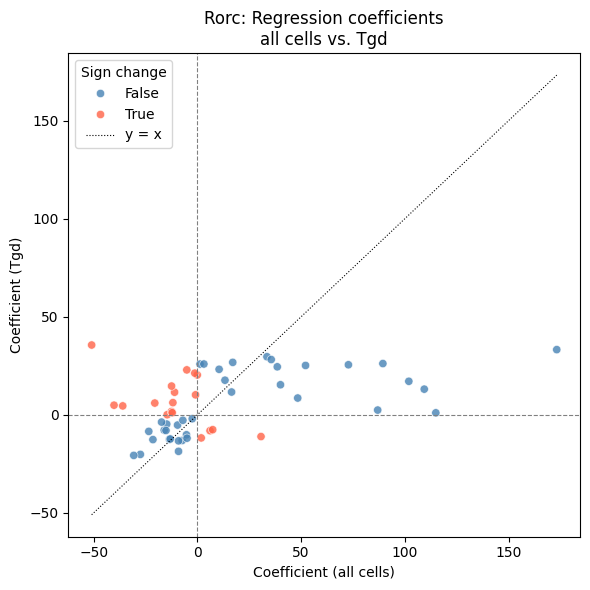

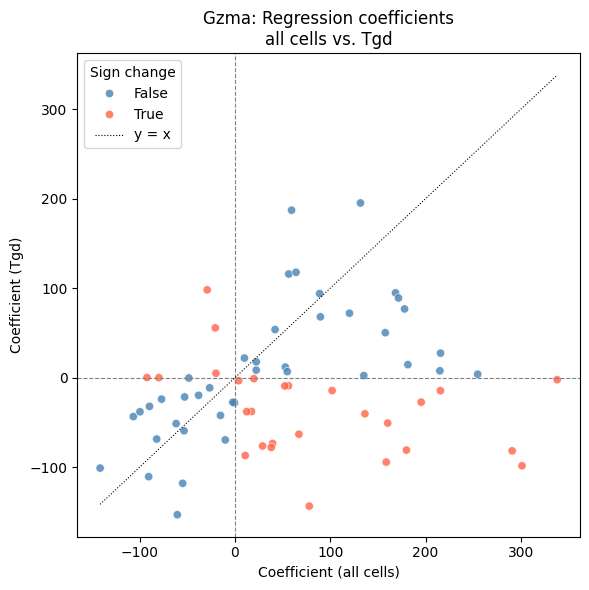

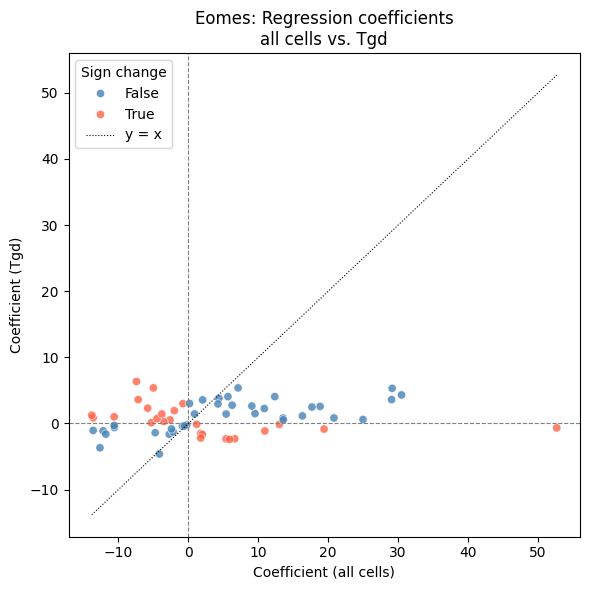

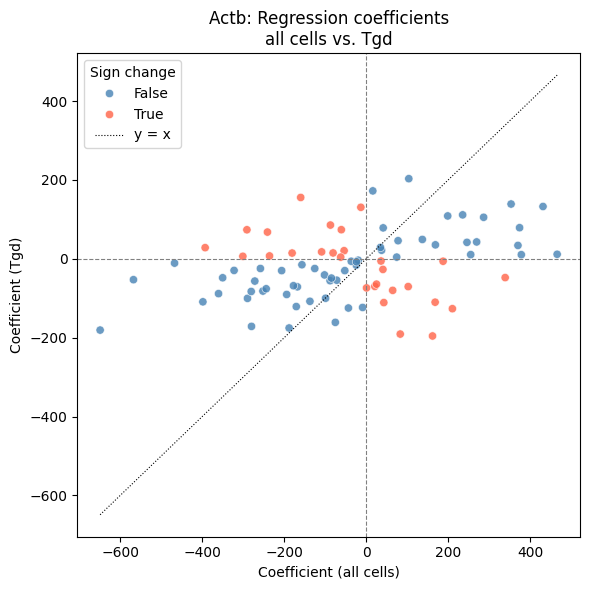

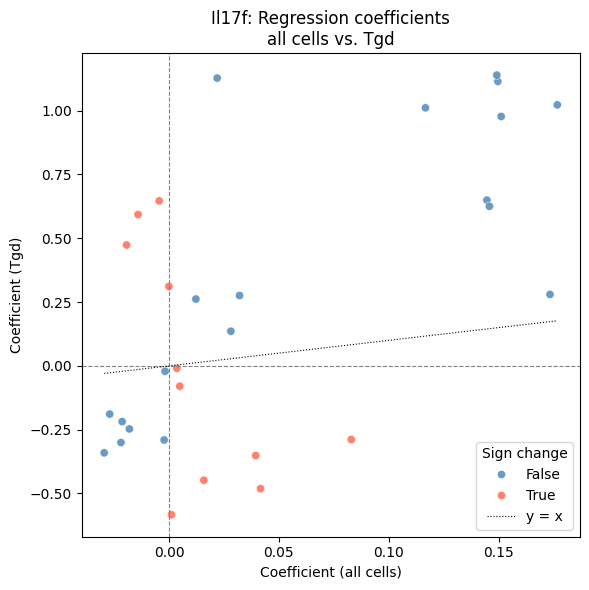

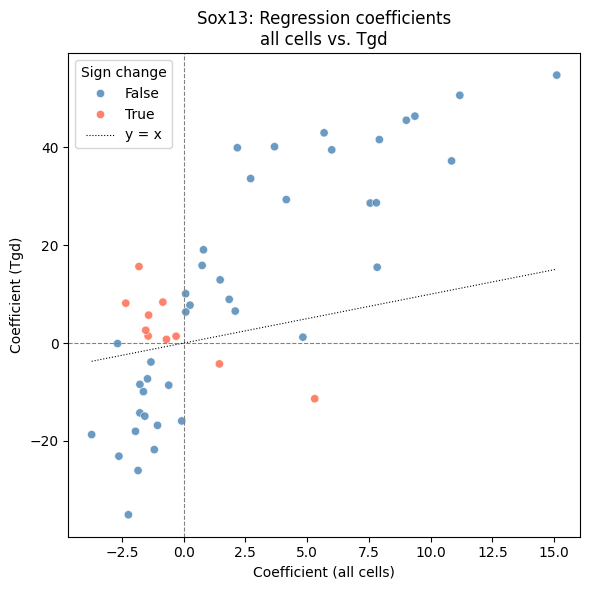

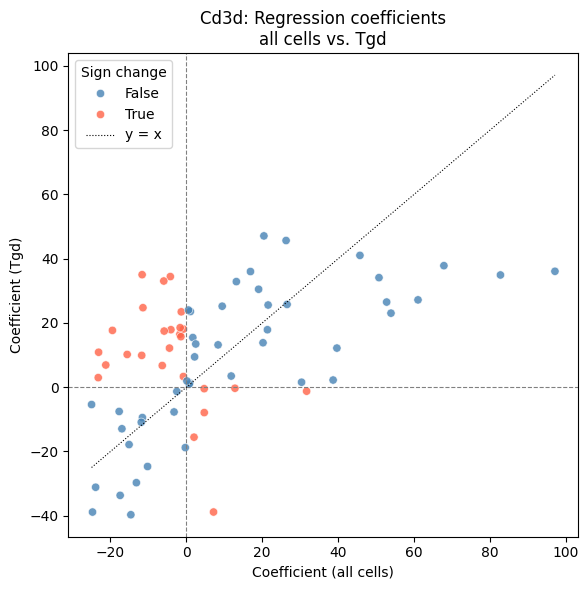

In [11]:
for gen in ["Rorc", "Gzma", "Eomes", "Actb", "Il17f", "Sox13", "Cd3d"]:
    scattplot_coef(gen)

Actb (Houskeeping): Pukte sind relativ symmetrisch um diagonale verteilt --> Scatterplot ähnlcih wie bei den anderen

Il17f: Rigid Modell sieht kein klares Muster --> ist sehr tgd spezifisch, also in all cells fast unsichtbar --> bei tgd overfitting modell, versucht irgendwie sinnvollen koeffizient draus zumachen --> grenzen des Modells

Gzma, Eomes und Rorc ähnlch wie Actb verhält sind auch grenzen unseres modells und gleichzeitig sagt, das auch, dass Gzma,Eomes und Rorc über alle zellen hinaus eine gloabel stabile Beziehung.

## Which CREs drive expression of your lineage-specific genes?

In [13]:
high_gini_Tgd = ["Il17f", "Cd3d", "Rorc"]# "Gzma", "Kcnk1", "Rorc", "Sox13", "Il17f", "Cd3d"

for gen in high_gini_Tgd:
    # filtern absolut
    filtered = coef_tables[gen][abs(coef_tables[gen]["Tgd"]) > abs(coef_tables[gen]["all_cells"])].copy()
    
    #spalte für den absoluten Abstand
    filtered["abs_distance"] = filtered["Tgd"].abs()
    
    #Nach absolutem Abstand sortieren und Spalte dann löschen
    top_drive = filtered.sort_values("abs_distance", ascending=False).drop(columns=["abs_distance"]) 
    
    #filtern anch positiv
    #top_drive = coef_tables[gen][  
        #to-drive Filter: Tgd coefficient am unterschiedlichsten als all cells coefficient
       # abs(coef_tables[gen]["Tgd"]) > abs(coef_tables[gen]["all_cells"])
    #].sort_values("Tgd", ascending=False) #sortiert mit größten Absatnd oben

    print(f"\n{gen} – Top Tγδ-driving CREs:")
    print(top_drive.head(10))


Il17f – Top Tγδ-driving CREs:
                          all_cells       Tgd   gene
ImmGenATAC1219.peak_2090   0.149211  1.139377  Il17f
ImmGenATAC1219.peak_2086   0.021907  1.127834  Il17f
ImmGenATAC1219.peak_2075   0.149677  1.114854  Il17f
ImmGenATAC1219.peak_2095   0.176759  1.022718  Il17f
ImmGenATAC1219.peak_2089   0.116722  1.011223  Il17f
ImmGenATAC1219.peak_2081   0.151196  0.977415  Il17f
ImmGenATAC1219.peak_2083   0.144711  0.649584  Il17f
ImmGenATAC1219.peak_2109  -0.004486  0.646648  Il17f
ImmGenATAC1219.peak_2085   0.145833  0.625246  Il17f
ImmGenATAC1219.peak_2116  -0.014109  0.593164  Il17f

Cd3d – Top Tγδ-driving CREs:
                            all_cells        Tgd  gene
ImmGenATAC1219.peak_482211  20.444442  47.107933  Cd3d
ImmGenATAC1219.peak_482197  26.288307  45.671452  Cd3d
ImmGenATAC1219.peak_482235 -14.626588 -39.689922  Cd3d
ImmGenATAC1219.peak_482172 -24.734433 -38.852603  Cd3d
ImmGenATAC1219.peak_482176   7.168351 -38.841240  Cd3d
ImmGenATAC1219.peak_482202

**Visualization** <br>ridge regression to rank ATAC peaks within ±100 kb of each gene based on their contribution to predicting gene expression across cell types, and selected the top 5 Tγδ biased peaks per gene for visualization

/var/folders/cc/3r9cpp9s7c9_s16wz91nlkn40000gn/T/ipykernel_53835/2469504633.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


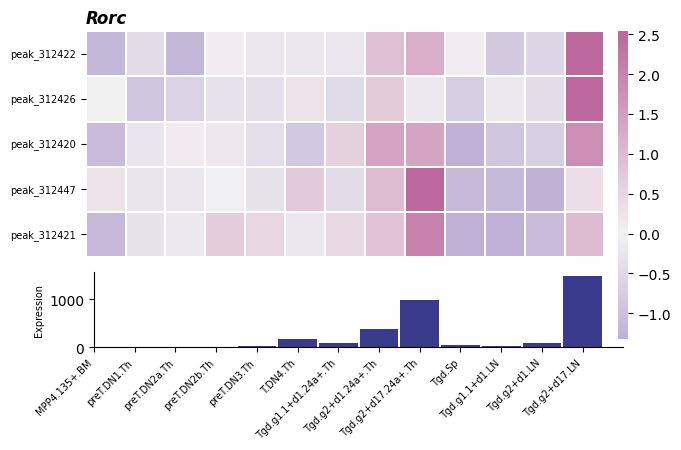

In [18]:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.preprocessing import StandardScaler

    Tgd_cells = [
        "MPP4.135+.BM",
        "preT.DN1.Th",
        "preT.DN2a.Th",
        "preT.DN2b.Th",
        "preT.DN3.Th",
        "T.DN4.Th",
        "Tgd.g1.1+d1.24a+.Th",
        "Tgd.g2+d1.24a+.Th",
        "Tgd.g2+d17.24a+.Th",
        "Tgd.Sp",
        "Tgd.g1.1+d1.LN",
        "Tgd.g2+d1.LN",
        "Tgd.g2+d17.LN"
    ]

    cmap = sns.diverging_palette(
        280,
        330,
        s=45,
        l=55,
        center="light",
        as_cmap=True
    )

    genes = ["Rorc"]#, "Il17f", "Cd3d", "Rorc"

    fig = plt.figure(figsize=(7, 4 * len(genes)))
    outer = fig.add_gridspec(
        len(genes), 2,
        width_ratios=[50, 1],
        wspace=0.05,
        hspace=0.7
    )

    for i, gen in enumerate(genes):
        # Inneres gridspec: Heatmap oben (3 Teile), Barplot unten (1 Teil)
        inner = outer[i, 0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

        ax_heat = fig.add_subplot(inner[0])
        ax_bar = fig.add_subplot(inner[1], sharex=ax_heat)
        cax = fig.add_subplot(outer[i, 1])

        #Heatmap 
        #top 5 peaks von jedem gen nach Regressionsmodell: positiv Tgd peak und größten unterschied zu all cells
        top5 = coef_tables[gen][
            #(coef_tables[gen]["Tgd"] > 0) &
             abs(coef_tables[gen]["Tgd"]) > abs(coef_tables[gen]["all_cells"])
            #(coef_tables[gen]["Tgd"] > coef_tables[gen]["all_cells"])
        ].sort_values("Tgd", ascending=False).head(5)

        #jede zeile ist ein peak dieser top5 und davon die ATAC zugäglichkeit
        rows = []
        for peak_id in top5.index:
            row = ATAC_seq_gd[ATAC_seq_gd["ImmGenATAC1219.peakID"] == peak_id]
            if not row.empty:
                vals = row[Tgd_cells].iloc[0]
                sauberer_name = peak_id.replace("ImmGenATAC1219.", "")
                vals.name = sauberer_name

            
                rows.append(vals)

        heat_df = pd.DataFrame(rows)
        heat_df_z = StandardScaler().fit_transform(heat_df.T) # skaliert über Tgd-Zelltypen je Peak (dafür transformieren) --> damit alle peaks auf derselben skala liegen (z=2: Standartabweichung 2 besonders offen für den peak)
        heat_df_z = pd.DataFrame(heat_df_z.T, index=heat_df.index, columns=heat_df.columns)

        sns.heatmap(
            heat_df_z,
            ax=ax_heat,
            cmap=cmap,
            center=0,
            robust=True,
            linewidths=0.3,
            xticklabels=False,
            yticklabels=True,
            cbar=True,
            cbar_ax=cax
        )

        ax_heat.set_title(gen, fontstyle="italic", fontweight="bold", loc="left")

        # Heatmap-Zellnamen kleiner
        ax_heat.tick_params(axis='x', labelbottom=False, bottom=False)   # z.B. 7 oder 8
        ax_heat.tick_params(axis='y', labelsize=7)   # z.B. 7 oder 8

        rna_row = RNA_seq_gd[RNA_seq_gd["Unnamed: 0"] == gen]
        # Barplot RNA: RNA‑Expression des Gens in den Tγδ‑Zelltypen
        if not rna_row.empty:
            rna_vals = rna_row[Tgd_cells].iloc[0]

            ax_bar.bar(
                np.arange(len(Tgd_cells)),
                rna_vals.values,
                width=0.95,
                color="#3a3a8c"
            )
            ax_bar.set_xticks(np.arange(len(Tgd_cells)))
            ax_bar.set_xticklabels(Tgd_cells, rotation=45, ha="right", fontsize=7)
            ax_bar.set_ylabel("Expression", fontsize=7)
            ax_bar.spines[["top", "right"]].set_visible(False)

        ax_heat.set_xlim(0, len(Tgd_cells))
        ax_bar.set_xlim(0, len(Tgd_cells))

        heat_pos = ax_heat.get_position()
        bar_pos = ax_bar.get_position()

        # Barplot nach rechts, nach unten und etwas länger
        ax_bar.set_position([
            heat_pos.x0 + 0.012,      # nach rechts
            bar_pos.y0 - 0.02,        # nach unten
            heat_pos.width + 0.015,   # etwas länger/breiter
            bar_pos.height
        ])
    # plt.savefig(f"plots_for_poster/top_peaks_ATAC_RNA_{genes}", dpi=300, bbox_inches="tight")
    plt.savefig(f"plots_for_poster/top_peaks_ATAC_RNA_Rorc", dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

für jedes Gen die Top‑5 Peaks nach Tγδ‑Koeffizienten bestimmt (die stärksten positiven Regressionskoeffizienten aufweisen und deren Einfluss dort größer ist als im all cells Modell)

* oben: ATAC‑Zugänglichkeit dieser Peaks über alle Zelltypen (Heatmap),

* unten: RNA‑Expression des Gens in denselben Zelltypen (Balken).

<br> Beobachtung

* In welchen Tγδ‑Subtypen sind diese „modell‑wichtigen“ CREs am stärksten offen
* Ob das Gen dort am stärksten exprimiert ist

Es wird sichtbar, in welchen Tγδ stadien hohe enhancer Aktivität und hohe Genexpression zusammenfallen, also wo die durch das Regressionsmodell identifizierten CREs die lineage spezifische Expression am stärksten zu treiben scheinen.

Peaks durch Modell gewählt --> ABER nicht dazu, dass sie quantitativ etwas bestimmen, also das ein bestimmter Peak einen bestimmten % Anteil der Varianz erklärt, das funktioniert nciht, weil es zu unzuverlässig ist

**Interpretation**
* Eomes: spät/Tγδ spezifische CREs, vllt für Reifung in bestimmten Geweben relevant
* Gzma: breitere Expression über mehrere Tgd‑Subtypen und erhöhte Zugänglichkeit in mehreren dieser Tgd‑Subsets
* Kck1: LN‑spezifisch in Tγδ‑Zellen aktiviert zu sein
* Rorc und Sox13: spät aber auch vor allem Il17f spez.


WICHTIG ZU SCHAUEN ON DAS ENHANCERS SIND UND DANNA AGUMENTIEREN FOLGEN ENAHNCER UND NICHT PROMOTOR DRIVEN LOGIC: plot sieht gleich wenn man davor TSS raus macht oder auch nicht

                          all_cells       Tgd   gene
ImmGenATAC1219.peak_2090   0.149211  1.139377  Il17f
ImmGenATAC1219.peak_2086   0.021907  1.127834  Il17f
ImmGenATAC1219.peak_2075   0.149677  1.114854  Il17f
ImmGenATAC1219.peak_2095   0.176759  1.022718  Il17f
ImmGenATAC1219.peak_2089   0.116722  1.011223  Il17f


/var/folders/cc/3r9cpp9s7c9_s16wz91nlkn40000gn/T/ipykernel_53835/2430289197.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


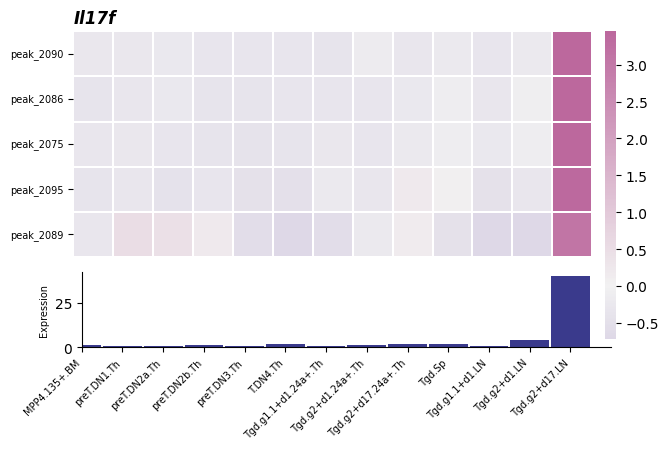

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

Tgd_cells = [
        "MPP4.135+.BM",
        "preT.DN1.Th",
        "preT.DN2a.Th",
        "preT.DN2b.Th",
        "preT.DN3.Th",
        "T.DN4.Th",
        "Tgd.g1.1+d1.24a+.Th",
        "Tgd.g2+d1.24a+.Th",
        "Tgd.g2+d17.24a+.Th",
        "Tgd.Sp",
        "Tgd.g1.1+d1.LN",
        "Tgd.g2+d1.LN",
        "Tgd.g2+d17.LN"
    ]

cmap = sns.diverging_palette(
        280,
        330,
        s=45,
        l=55,
        center="light",
        as_cmap=True
    )

genes = ["Il17f"]#, "Il17f", "Cd3d", "Rorc"

fig = plt.figure(figsize=(7, 4 * len(genes)))
outer = fig.add_gridspec(
        len(genes), 2,
        width_ratios=[50, 1],
        wspace=0.05,
        hspace=0.7
    )

for i, gen in enumerate(genes):
        # Inneres gridspec: Heatmap oben (3 Teile), Barplot unten (1 Teil)
        inner = outer[i, 0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

        ax_heat = fig.add_subplot(inner[0])
        ax_bar = fig.add_subplot(inner[1], sharex=ax_heat)
        cax = fig.add_subplot(outer[i, 1])

        filtered_coef = coef_tables[gen][abs(coef_tables[gen]["Tgd"]) > abs(coef_tables[gen]["all_cells"])].copy()
        top5 = filtered_coef.sort_values("Tgd", ascending=False).head(5)
        print(top5)


        #Heatmap 
        #top 5 peaks von jedem gen nach Regressionsmodell: positiv Tgd peak und größten unterschied zu all cells
        #top5 = coef_tables[gen][
            #(coef_tables[gen]["Tgd"] > 0) &
             #abs(coef_tables[gen]["Tgd"]) > abs(coef_tables[gen]["all_cells"])
            #(coef_tables[gen]["Tgd"] > coef_tables[gen]["all_cells"])
        #].sort_values("Tgd", ascending=False).head(5)

        #jede zeile ist ein peak dieser top5 und davon die ATAC zugäglichkeit
        rows = []
        for peak_id in top5.index:
            row = ATAC_seq_gd[ATAC_seq_gd["ImmGenATAC1219.peakID"] == peak_id]
            if not row.empty:
                vals = row[Tgd_cells].iloc[0]
                sauberer_name = peak_id.replace("ImmGenATAC1219.", "") #ImmgenATAC1219 in y-Achse Beschriftung rausgenommen
                vals.name = sauberer_name
                rows.append(vals)

        heat_df = pd.DataFrame(rows)
        heat_df_z = StandardScaler().fit_transform(heat_df.T) # skaliert über Tgd-Zelltypen je Peak (dafür transformieren) --> damit alle peaks auf derselben skala liegen (z=2: Standartabweichung 2 besonders offen für den peak)
        heat_df_z = pd.DataFrame(heat_df_z.T, index=heat_df.index, columns=heat_df.columns)

        sns.heatmap(
            heat_df_z,
            ax=ax_heat,
            cmap=cmap,
            center=0,
            robust=True,
            linewidths=0.3,
            xticklabels=False,
            yticklabels=True,
            cbar=True,
            cbar_ax=cax
        )

        ax_heat.set_title(gen, fontstyle="italic", fontweight="bold", loc="left")

        # Heatmap-Zellnamen kleiner
        ax_heat.tick_params(axis='x', labelbottom=False, bottom=False)   # z.B. 7 oder 8
        ax_heat.tick_params(axis='y', labelsize=7)   # z.B. 7 oder 8

        rna_row = RNA_seq_gd[RNA_seq_gd["Unnamed: 0"] == gen]
        # Barplot RNA: RNA‑Expression des Gens in den Tγδ‑Zelltypen
        if not rna_row.empty:
            rna_vals = rna_row[Tgd_cells].iloc[0]

            ax_bar.bar(
                np.arange(len(Tgd_cells)),
                rna_vals.values,
                width=0.95,
                color="#3a3a8c"
            )
            ax_bar.set_xticks(np.arange(len(Tgd_cells)))
            ax_bar.set_xticklabels(Tgd_cells, rotation=45, ha="right", fontsize=7)
            ax_bar.set_ylabel("Expression", fontsize=7)
            ax_bar.spines[["top", "right"]].set_visible(False)

        ax_heat.set_xlim(0, len(Tgd_cells))
        ax_bar.set_xlim(0, len(Tgd_cells))

        heat_pos = ax_heat.get_position()
        bar_pos = ax_bar.get_position()

        # Barplot nach rechts, nach unten und etwas länger
        ax_bar.set_position([
            heat_pos.x0 + 0.012,      # nach rechts
            bar_pos.y0 - 0.02,        # nach unten
            heat_pos.width + 0.015,   # etwas länger/breiter
            bar_pos.height
        ])
#plt.savefig(f"plots_for_poster/top_peaks_ATAC_RNA_{genes}", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

## Peter

In [ ]:
plt.savefig('plots for poster/Regression', dpi=300)

NameError: name 'plt' is not defined

#### Ammending the Plot - Peter

##### Einfach zu klappen und laufen lassen

In [ ]:
#Datasets
import numpy as np
import pandas as pd
import seaborn as sns  
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline 
from pathlib import Path


#RNA Data
RNA_seq_path = Path('data') / 'mmc2.csv'
RNA_seq = pd.read_csv(RNA_seq_path)
RNAseq_reg = RNA_seq.copy()

##ATAC Data general
ATAC_path = Path('data') / 'ImmGenATAC18_AllOCRsInfo.csv'
ATAC_data = pd.read_csv(ATAC_path)

##ATAC Data without unreliable Data
threshold = -np.log10(0.05)
ATAC_data_removed = ATAC_data[ATAC_data["_-log10_bestPvalue"] >= threshold].copy()
ATAC_data_removed.__len__() 

annotation_cols = [
    "ImmGenATAC1219.peakID",
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATACseq_reg = ATAC_data_removed[ATAC_data_removed["TSS"].isnull()]


print(RNAseq_reg.head())


      Unnamed: 0  LTHSC.34-.BM  LTHSC.34+.BM  STHSC.150-.BM  MPP4.135+.BM  \
0  0610005C13Rik      1.096732      1.096732       1.021750      1.021812   
1  0610007P14Rik    206.053987    246.105317     192.424636    204.298358   
2  0610009B22Rik     78.272059     78.837030      68.844751     76.418169   
3  0610009L18Rik      8.577159     16.791386      15.511549     16.947354   
4  0610009O20Rik    168.645852    157.926022     155.941641    186.261464   

   proB.CLP.BM  proB.FrA.BM  proB.FrBC.BM    B.FrE.BM      B1b.PC  ...  \
0     1.205236     1.326780      1.392996    1.821243    1.025543  ...   
1   189.759175   210.195155    180.219440  137.802543  139.436719  ...   
2   106.085619    77.502817     68.213092   57.224426   56.787489  ...   
3    10.583704     8.664784      2.878172    8.952120   11.873984  ...   
4   162.584556   152.088002    163.072291  133.116083   88.052982  ...   

        MF.PC   MF.Fem.PC    DC.4+.Sp    DC.8+.Sp   DC.pDC.Sp     FRC.SLN  \
0    1.025785  

In [ ]:
#build_gene_peak_dict(ATAC_seq)

def build_gene_peak_dict(ATAC_seq):

    gene_to_peaks = {}

    ATAC_filtered = ATAC_seq[ATAC_seq["genes.within.100Kb"].notna()]

    for index, row in ATAC_filtered.iterrows():

        peak_ID = row["ImmGenATAC1219.peakID"]

        for gene in str(row["genes.within.100Kb"]).split(","):
            
            gene = gene.strip()

            if gene not in gene_to_peaks:
                gene_to_peaks[gene] = []
            
            gene_to_peaks[gene].append(peak_ID)

    return gene_to_peaks

gene_peak_dictionary = build_gene_peak_dict(ATAC_data_removed)

In [ ]:
#f: r2_gen_TSS

ATACseq_reg_TSS = ATAC_data_removed.copy()

def r2_gen_TSS(gen_name, plot=True, plot_residues = True):
    #Y_RNA
    RNA_seq_Gene = RNAseq_reg[RNAseq_reg["Unnamed: 0"] == gen_name]
    y = RNA_seq_Gene.drop("Unnamed: 0", axis=1, errors="ignore").T

    #X_ATAC
    peak_ids = gene_peak_dictionary.get(gen_name, [])
    ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["ImmGenATAC1219.peakID"].isin(peak_ids)]

    ##ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]
    ##peak_ids = ATACseq_reg_TSS["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_Gene.drop(annotation_cols, axis=1, errors="ignore").T
    
    #Index angleichen
    common_cells = X.index.intersection(y.index)
    X = X.loc[common_cells]
    y = y.loc[common_cells]

    #Standardscale and choosing best alpha
    X_scaled = StandardScaler().fit_transform(X)
    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # CV mit bestem alpha
    cv = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
        X, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()

    #für Vergleich von Y
    y_actual = np.ravel(y.values).flatten()
    y_pred = ridge.predict(X_scaled).flatten()

    if plot:
        Reg_vis = pd.DataFrame({"y_actual": y_actual, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100)
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=False,
                    ci=None, line_kws={"color": "red"})
        plt.title(f"Actual vs Predicted y for {gen_name}-Expression across all cells inkl. TSS")
        plt.show()

    if plot_residues:
        residuals = y_actual - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name}-Expression across all cells inkl. TSS")
        plt.show()
        
    return  r2, cv, ridge


for gen_name in ["Il17f", "Rorc", "Sox13", "Gzma", "Eomes", "Actb"]: 
    r2, cv, ridge= r2_gen_TSS(gen_name, plot=False, plot_residues=False)
    print(f"{gen_name}_all: R²={r2:.3f}, CV={cv:.3f}")

Il17f_all: R²=0.054, CV=-4.165
Rorc_all: R²=0.905, CV=0.659
Sox13_all: R²=0.450, CV=-203.209
Gzma_all: R²=0.986, CV=0.899
Eomes_all: R²=0.986, CV=0.928
Actb_all: R²=0.633, CV=0.163


In [ ]:
#f: coef_gen

def coef_gen(gen_name):
    r2, cv, ridge = r2_gen_TSS(gen_name, plot=False, plot_residues=False) #Falls Error: Anpassen welche Ridge Funktion benutzt wird!

    ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]
    peak_ids = ATAC_seq_Gene["ImmGenATAC1219.peakID"].values

    coef_df = pd.DataFrame({"peak_id": peak_ids, "coefficient": ridge.coef_})

    #eine Spalte soll direkt Vorzeicehn interpretieren
    coef_df["sign"] = coef_df["coefficient"].apply(lambda x: "+" if x > 0 else "-")

    # Effektstärke
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs().round(1)

    #inaktiv# Sortieren aktiv und repressvi
    #coef_df["sign_order"] = coef_df["sign"].map({"repressing": 0,"activating": 1})

    # zuerst repressing/activating, dann nach Stärke
    coef_df = coef_df.sort_values(by=["abs_coefficient"], ascending=[False])

    #inaktiv# Hilfsspalte wieder entfernen
    ##coef_df = coef_df.drop(columns="sign_order")

    return coef_df, r2, cv, peak_ids

coef_Gzma, r2, cv, peak_ids = coef_gen("Gzma")
coef_Gzma["abs_coefficient"].describe()
coef_Gzma

,peak_id,coefficient,sign,abs_coefficient
26,ImmGenATAC1219.peak_142098,715.915569,+,715.9
21,ImmGenATAC1219.peak_142093,486.993120,+,487.0
53,ImmGenATAC1219.peak_142129,412.479079,+,412.5
40,ImmGenATAC1219.peak_142114,409.974730,+,410.0
22,ImmGenATAC1219.peak_142094,-393.385473,-,393.4
...,...,...,...,...
46,ImmGenATAC1219.peak_142120,-8.826416,-,8.8
67,ImmGenATAC1219.peak_142147,8.322973,+,8.3
55,ImmGenATAC1219.peak_142133,-7.726329,-,7.7
64,ImmGenATAC1219.peak_142144,-2.435170,-,2.4


In [ ]:
#creating plot_df

genes = ["Rorc", "Il17f", "Eomes"]
strong_threshold = 10

plot_rows = []

for gene in genes:
    coef_df, r2, cv, peak_ids = coef_gen(gene)

    coef_df["category"] = "weak activator"

    coef_df.loc[
        coef_df["coefficient"] < 0,
        "category"
    ] = "repressor"

    coef_df.loc[
        coef_df["coefficient"] >= strong_threshold,
        "category"
    ] = "strong activator"

    temp = coef_df[["peak_id", "coefficient", "category"]].copy()
    temp["gene"] = gene

    plot_rows.append(temp)

plot_df = pd.concat(plot_rows, ignore_index=True)

display(
    plot_df.groupby(["gene", "category"]).size()
)

gene   category        
Eomes  repressor           28
       strong activator    16
       weak activator      18
Il17f  repressor           11
       weak activator      19
Rorc   repressor           32
       strong activator    18
       weak activator       5
dtype: int64

##### Hier Plot verändern

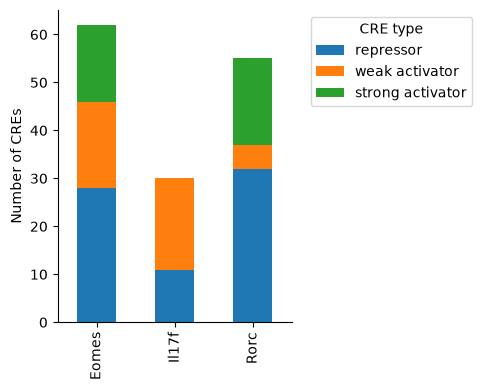

In [ ]:
#creating plot

plot_counts = (
    plot_df
    .groupby(["gene", "category"])
    .size()
    .unstack(fill_value=0)
)

plot_counts = plot_counts[
    ["repressor",
     "weak activator",
     "strong activator"]
]

ax = plot_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(5,4)
)

ax.set_ylabel("Number of CREs")
ax.set_xlabel("")
ax.legend(
    title="CRE type",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

In [57]:
# combining plots